# 02 Exploratory Data Analysis (EDA)

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

import sys
from pathlib import Path

SRC_PATH = Path.cwd().parent / "src"
sys.path.append(str(SRC_PATH))

## 1. Data Loading

### 1.1 Read review_analysis.db database

In [2]:
# Connect to the database
conn = sqlite3.connect("../data/reviews_analysis.db")

# Read all table in the database
hotels_df = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'",
    conn
)

* Convert to pandas dataframe

In [3]:
# Print our table name
tables = hotels_df['name'].tolist()
tables

['reviews', 'authors', 'hotels']

In total we have 3 tables:
1. Reviews
2. Authors
3. Hotels

### Save dataset as dictionary

In [4]:
# Create empty dictionary
dataset = {}

# Query all data from every tables
for table in tables:
    query = f"SELECT * FROM {table}"
    dataset[table] = pd.read_sql(query, conn)

In [5]:
# Print dictionary keys to ensure the tables are in
dataset.keys()

dict_keys(['reviews', 'authors', 'hotels'])

In [6]:
# Print every column and data type for each table
for table in dataset.keys():
    print(f'\nTable name:   {table}')
    print(f'{dataset[table].dtypes}')


Table name:   reviews
title                          str
text                           str
date_stayed                    str
hotel_id                       str
num_helpful_votes            int64
review_date                    str
review_id                      str
via_mobile                   int64
service_rating             float64
cleanliness_rating         float64
overall_rating             float64
value_rating               float64
location_rating            float64
sleep_quality_rating       float64
rooms_rating               float64
check_in_service_rating    float64
business_service_rating    float64
author_id                      str
dtype: object

Table name:   authors
id                       str
username                 str
num_cities           float64
num_helpful_votes    float64
num_reviews          float64
num_type_reviews     float64
location                 str
alias                    str
dtype: object

Table name:   hotels
hotel_id                           str
num

Most of the features name and data dtype looks correct except for the date. So the following code is to cast the date to pandas datetime.

### Converting dates to datetime

In [7]:
# Convert 'date_stayed' to datetime
dataset['reviews']['date_stayed'] = pd.to_datetime(
    dataset['reviews']['date_stayed'],
    errors='coerce'
)

# Convert 'review_date' to datetime
dataset['reviews']['review_date'] = pd.to_datetime(
    dataset['reviews']['review_date'],
    errors='coerce'
)

In [8]:
# Show
dataset['reviews']['date_stayed'].isna().sum()

np.int64(0)

### Quick check for data validity

At some point, we might have irrelevant data where the date_stayed of the user is empty, in this case we can just drop it even if the data is not nan just for safety reason.

In [9]:
# Remove NaN entry from the reviews if the date_stayed is empty
dataset['reviews'].dropna(subset='date_stayed', inplace=True)

In [10]:
# Print
print(f"length of data after dropping: {len(dataset['reviews'])}")

length of data after dropping: 80000


If none of the data is deleted as seen above, then **the data is complete** in the first place.

### datetime data validity for relevancy

By checking the range of the date for review_date and stayed_date, we can validate data and increase data relevancy.

Rules:

Date is considered relevant if the day difference between review_date and the date_stayed is under 150 days.
This means that **the user review the hotel within 5 months** after their staying duration.

> **Why this step?** In our first iteration, there were some entries where the user review the hotel even 8 years after their staying duration.

In [11]:
reviews_df = dataset['reviews']

print(f"date_stayed date range:  {reviews_df['date_stayed'].min().strftime('%B %Y')} - {reviews_df['date_stayed'].max().strftime('%B %Y')}")
print(f"review_date date range:  {reviews_df['review_date'].min().strftime('%-d %B %Y')} - {reviews_df['review_date'].max().strftime('%-d %B %Y')}")

filtered = reviews_df[reviews_df['review_date'] - reviews_df['date_stayed'] <= pd.Timedelta(days=150)]
print(f'Count of valid data:     {len(filtered):,}')

date_stayed date range:  December 2007 - December 2012
review_date date range:  1 January 2008 - 20 December 2012
Count of valid data:     80,000


**What we have done so far:**
1. We have loaded all the tables in the dataset.
2. We have parse the datatype to the correct type for each column
3. We have done a quick check for data completeness and validity

---

## 2. Data Exploration & Feature Engineering

On this step, the column in the tables are valid, we can continue by exploring unique observations and findings from each table. During the process, we will also build some helpful features that might help us during the later steps.

### 2.1. Reviews table

In [12]:
reviews_df = dataset['reviews']
reviews_df.head()

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id
0,“Daaaaaa Bears!”,I recently stayed at W Chicago Lakeshore and o...,2012-11-01,225108,0,2012-11-19,145753174,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,714F49AC057498AEA304343E569A2A03
1,“Would go back in a heartbeat- Location Locati...,We booked this hotel after out initial travel ...,2010-09-01,122005,1,2010-10-02,81870377,0,3.0,5.0,4.0,5.0,5.0,5.0,3.0,NaN,NaN,74C5A4455E1AAE46B0C54FC6CCBD7033
2,"“Clean, Friendly, Affordable Alternative to Do...",I am currently here in the hotel; checking out...,2009-07-01,939375,2,2009-07-02,33732815,0,5.0,4.0,4.0,4.0,4.0,NaN,4.0,NaN,NaN,CC2C523A197E7024A07BE083E1573E75
3,"“Atrium pool, location and basic amenities wer...",Two 10 yr. olds enjoyed the large pool in the ...,2009-06-01,87573,1,2009-06-21,32773886,0,3.0,4.0,4.0,4.0,4.0,NaN,3.0,NaN,NaN,D879DE1351CB445AEF3B247EF25CFC00
4,“Very Good but Nothing Spectacular”,Stayed here on business because it was within ...,2009-08-01,123022,0,2009-08-19,38157829,0,4.0,5.0,4.0,3.0,3.0,NaN,3.0,NaN,NaN,404B9AF8897A742142CEBF4F0596EF5E


Now that the data date is valid and relevant, we can add new feature called 'review_days_since_stay' that denotes how long the review is given after the stay date.

#### 2.1.1. New columns: reviews_days_since_stay

We know that our user review their hotel within 5 months, but we don't have the exact day in the column and **our model will not be able to automatically derive this feature unless we define it**. So, let's create a new column called 'review_days_since_stay' the measures how many days do the user need until they finally leave a review.

In [13]:
# Create column reviews_days_since_stay
reviews_df['reviews_days_since_stay'] = reviews_df['review_date'] - reviews_df['date_stayed']
reviews_df.head(2)

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id,reviews_days_since_stay
0,“Daaaaaa Bears!”,I recently stayed at W Chicago Lakeshore and o...,2012-11-01,225108,0,2012-11-19,145753174,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,714F49AC057498AEA304343E569A2A03,18 days
1,“Would go back in a heartbeat- Location Locati...,We booked this hotel after out initial travel ...,2010-09-01,122005,1,2010-10-02,81870377,0,3.0,5.0,4.0,5.0,5.0,5.0,3.0,NaN,NaN,74C5A4455E1AAE46B0C54FC6CCBD7033,31 days


We start off with 1 helpful column, now we can start analyzing each column in the review table

#### 2.1.2. Analyze Columns

##### **Datetime**

In [14]:
# Analyse datetime columns
print('======== DATE ANALYSIS ========')
print(f"date_stayed date range:  {reviews_df['date_stayed'].min().strftime('%B %Y')} - {reviews_df['date_stayed'].max().strftime('%B %Y')}")
print(f"review_date date range:  {reviews_df['review_date'].min().strftime('%-d %B %Y')} - {reviews_df['review_date'].max().strftime('%-d %B %Y')}")

======== DATE ANALYSIS ========
date_stayed date range:  December 2007 - December 2012
review_date date range:  1 January 2008 - 20 December 2012


##### **Categorical**

In [15]:
# Categorical
print('======== CATEGORICAL ANALYSIS ========')
# Check the percentage of people with via_mobile = 1
print(f"{reviews_df['via_mobile'].mean():.2%} of people fill the review via mobile")

# Check the insight for each rating column
for col in ['service_rating', 'cleanliness_rating', 'overall_rating', 'value_rating', 'location_rating', 'sleep_quality_rating', 'rooms_rating', 'check_in_service_rating', 'business_service_rating']:
    
    print(f'\n- {col} average of all hotel is {reviews_df[col].mean():.1f} stars')                                # Average
    print(f'    - {(len(reviews_df[reviews_df[col] == 5]) / len(reviews_df)):.2%} of the rating is 5 stars')      # 5 stars rate
    print(f'    - {(len(reviews_df[reviews_df[col] == 1]) / len(reviews_df)):.2%} of the rating is 1 stars')      # 1 star rate
    
    # Count NaN entries
    nan_count = reviews_df[col].isna().sum()
    
    # Print percentage of NaN entries if exist
    if nan_count > 0:
        print(f'    - {(nan_count / len(reviews_df)):.2%} ({nan_count} entries) does not give any rating')

# Print the description of each column
reviews_df[['via_mobile','service_rating','cleanliness_rating','overall_rating','value_rating','location_rating','sleep_quality_rating','rooms_rating','check_in_service_rating','business_service_rating']].describe()

======== CATEGORICAL ANALYSIS ========
6.68% of people fill the review via mobile

- service_rating average of all hotel is 4.1 stars
    - 52.08% of the rating is 5 stars
    - 5.63% of the rating is 1 stars

- cleanliness_rating average of all hotel is 4.2 stars
    - 55.10% of the rating is 5 stars
    - 3.79% of the rating is 1 stars

- overall_rating average of all hotel is 4.0 stars
    - 41.82% of the rating is 5 stars
    - 5.14% of the rating is 1 stars

- value_rating average of all hotel is 3.9 stars
    - 40.79% of the rating is 5 stars
    - 5.86% of the rating is 1 stars

- location_rating average of all hotel is 4.4 stars
    - 62.04% of the rating is 5 stars
    - 1.60% of the rating is 1 stars

- sleep_quality_rating average of all hotel is 4.1 stars
    - 35.31% of the rating is 5 stars
    - 3.63% of the rating is 1 stars
    - 27.26% (21810 entries) does not give any rating

- rooms_rating average of all hotel is 4.0 stars
    - 40.73% of the rating is 5 stars
    -

,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,58190.000000,80000.000000,6337.00000,4315.000000
mean,0.066812,4.122675,4.249587,3.998413,3.930613,4.427613,4.100980,3.961125,4.01941,3.674160
std,0.249699,1.160277,1.047668,1.127664,1.167450,0.880480,1.121092,1.130975,1.19425,1.249188
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
25%,0.000000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.00000,3.000000
50%,0.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.00000,4.000000
75%,0.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000
max,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000


##### **Numerical**

In [16]:
# Numerical
print('======== NUMERICAL ANALYSIS ========')

reviews_df[['num_helpful_votes']].describe()

======== NUMERICAL ANALYSIS ========


,num_helpful_votes
count,80000.00000
mean,0.64005
std,1.25229
min,0.00000
25%,0.00000
50%,0.00000
75%,1.00000
max,103.00000


#### 2.1.3. Visualization

##### **Distribution of Reviews per Star Rating**

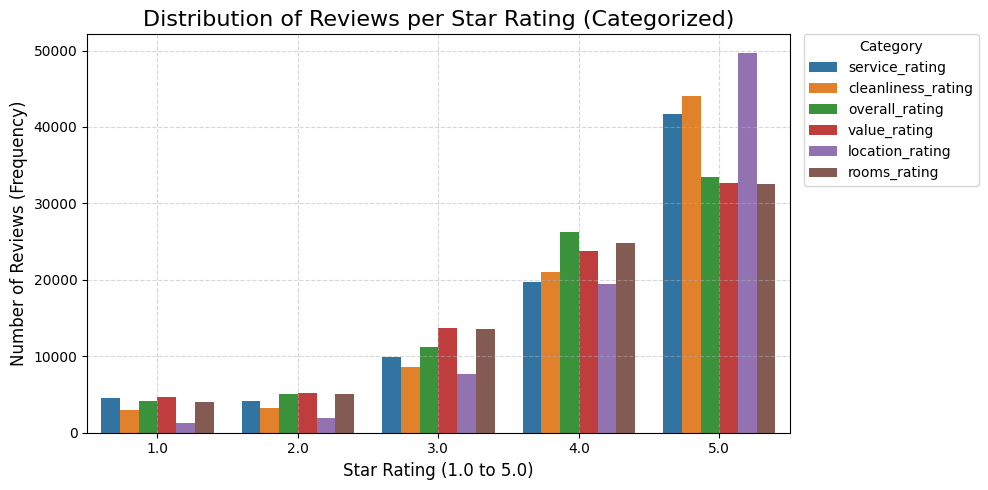

In [17]:
# Set which column will be used for count plot
# We exclude sleep quality rating, check_in_service_rating, business_service_rating because the metrics have low entry
review_num_cols = ['service_rating','cleanliness_rating','overall_rating','value_rating','location_rating','rooms_rating']

# The initial matplotlib script is generated with the help of Gemini AI
# https://gemini.google.com/share/d81a3d2d792b

# Melt by category and rating
df_melted = reviews_df[review_num_cols].melt(var_name="Category",value_name="Rating")

# Ensure Rating is treated as a categorical variable from 1 to 5 to show all bins
df_melted['Rating'] = pd.Categorical(df_melted['Rating'], categories=[1.0, 2.0, 3.0, 4.0, 5.0])

# Plotting
plt.figure(figsize=(10, 5))
sns.countplot(data=df_melted, x="Rating", hue="Category")

# Customizing labels
plt.title('Distribution of Reviews per Star Rating (Categorized)', fontsize=16)
plt.xlabel('Star Rating (1.0 to 5.0)', fontsize=12)
plt.ylabel('Number of Reviews (Frequency)', fontsize=12)
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.grid(linestyle='--', alpha=0.5)

plt.tight_layout()


Key observations (without considering check in rating and business service rating):

* **5 Stars** rating are mostly given due to **customer's satisfaction with location, cleanliness, and service**.
* **1 Star** rating are mostly given due to **customer's dissatisfaction with value, service, overall, and rooms rating**.
* **Feature wise**, location is the one that greatly satisfies the customer. Meanwhile, value and rooms are two features that has more diverse reviews which is probably due to higher subjective expectation.

This can be a good insight for a hotel to know which aspect they should prioritize for their business strength and strategy.


##### **Distribution of Reviews per Category**

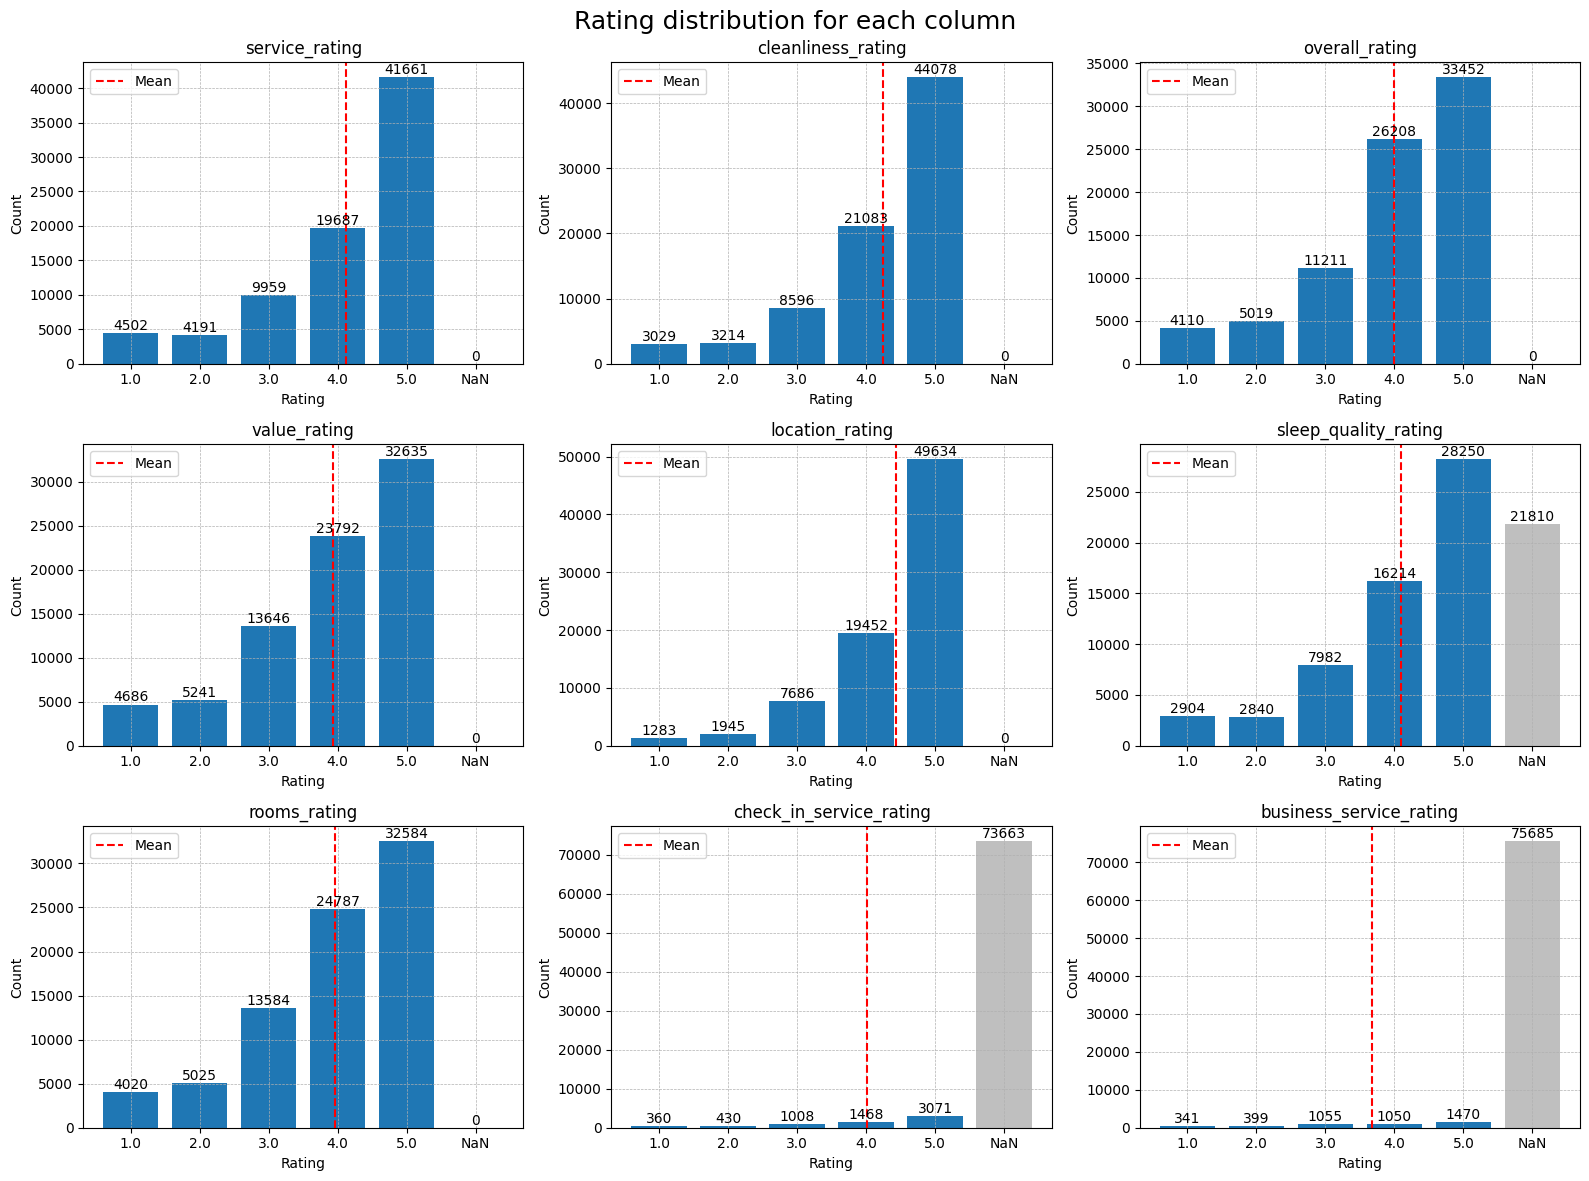

In [18]:
rating_column = ['service_rating','cleanliness_rating','overall_rating','value_rating','location_rating','sleep_quality_rating','rooms_rating','check_in_service_rating','business_service_rating']

# Prepare subplot (3x3 for compactness)
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(16,12))
ax = ax.flatten()

# Loop for each column
for i, col in enumerate(rating_column):
    
    # Get the mean for vertical line
    mean = reviews_df[col].mean()
    
    # Replace NaN with string "NaN"
    reviews_df_filled = reviews_df[col].fillna('NaN').astype(str)
    
    # Do value_counts()
    counts = reviews_df_filled.value_counts()
    
    # Reindex so that we can show the NaN values as well
    counts = counts.reindex(['1.0', '2.0', '3.0', '4.0', '5.0', 'NaN'], fill_value=0)
    colors = ['C0'] * 5 + ['gray']      # Set the color of the bar for each index
    
    # Plot the bar in the subplot
    bars = ax[i].bar(counts.index, counts.values, color=colors)
    
    # Add counts on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax[i].text(bar.get_x() + bar.get_width()/2, height + 1, str(height), ha='center', va='bottom', fontsize=10)
    
    # Set the alpha of the NaN to semi-transparent
    bars[-1].set_alpha(0.5)
    
    # Only draw mean if numeric, ignore NaN
    if not np.isnan(mean):
        # Find position on x-axis
        mean_pos = mean - 1  # Subtract position by 1
        ax[i].axvline(mean_pos, color='red', linestyle='--', label='Mean')
        ax[i].legend()
        
    ax[i].set_title(f'{col}')
    ax[i].set_xlabel('Rating')
    ax[i].set_ylabel('Count')
    ax[i].grid(linestyle = '--', linewidth = 0.5)

plt.suptitle('Rating distribution for each column', fontsize=18)
plt.tight_layout()
plt.show()

Key Observations:
* **This confirms how location rating dominates** our dataset with the rating group seems left-skewed.
* On the other hand **value_rating still has the highest rate of 1-2 stars** among all features.

##### **Count for Number of Helpful Votes and Mobile Users**

/var/folders/9_/fy5p9d_52f9d3dxp8df05zlc0000gn/T/ipykernel_95369/1416910873.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(["False", "True"])


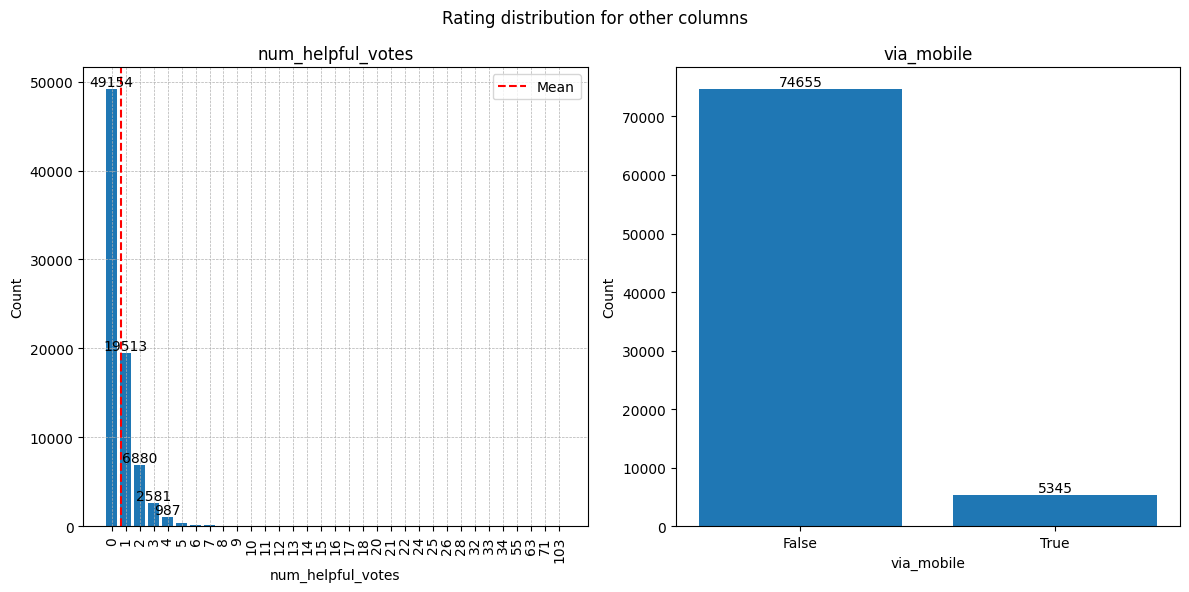

In [19]:
rating_column = ['num_helpful_votes', 'via_mobile',]

# Prepare subplots
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
ax = ax.flatten()

# Repeat for every column
for i, col in enumerate(rating_column):
    
    # Get the mean for vertical line
    mean = reviews_df[col].mean()
    
    # Replace NaN with string "NaN"
    reviews_df_filled = reviews_df[col].fillna('NaN').astype(str)
    
    # Do value_counts() and sort the index
    counts = reviews_df_filled.value_counts().sort_index(key=lambda x: pd.to_numeric(x, errors='coerce'))
    
    # Draw the bar chart
    bars = ax[i].bar(counts.index, counts.values)
    
    # Add counts on top of each bar (aligned to center of bar), hide insignificant value
    for bar in bars:
        
        height = bar.get_height()
        
        if height > 750:
            ax[i].text(bar.get_x() + bar.get_width()/2, height + 1, str(height), ha='center', va='bottom', fontsize=10)
    
    # For num_helpful_votes, we display a vertical line to show the mean, and add soft transparent grid
    if col == 'num_helpful_votes':
        ax[i].axvline(mean, color='red', linestyle='--', label='Mean')
        ax[i].legend()
        ax[i].grid(linestyle = '--', linewidth = 0.5)
        ax[i].tick_params(axis='x', rotation=90)
    
    # Print by string for better clarity
    if col == 'via_mobile':
        ax[i].set_xticklabels(["False", "True"])
    
    # Set title and label
    ax[i].set_title(f'{col}')
    ax[i].set_xlabel(rating_column[i])
    ax[i].set_ylabel('Count')

# add main title and prevent overlapping
plt.suptitle('Rating distribution for other columns')
plt.tight_layout()
plt.show()

Key observations:
* **Most of the reviews are not helpful**, however there are many data points where about 1-4 people vote it as helpful.
* **There are several reviews with a higher rate of helpful votes**. However, the count is extremely insignificant.
* **6.68% people fill the review via mobile** which is very low

##### **Correlation matrix of the features**

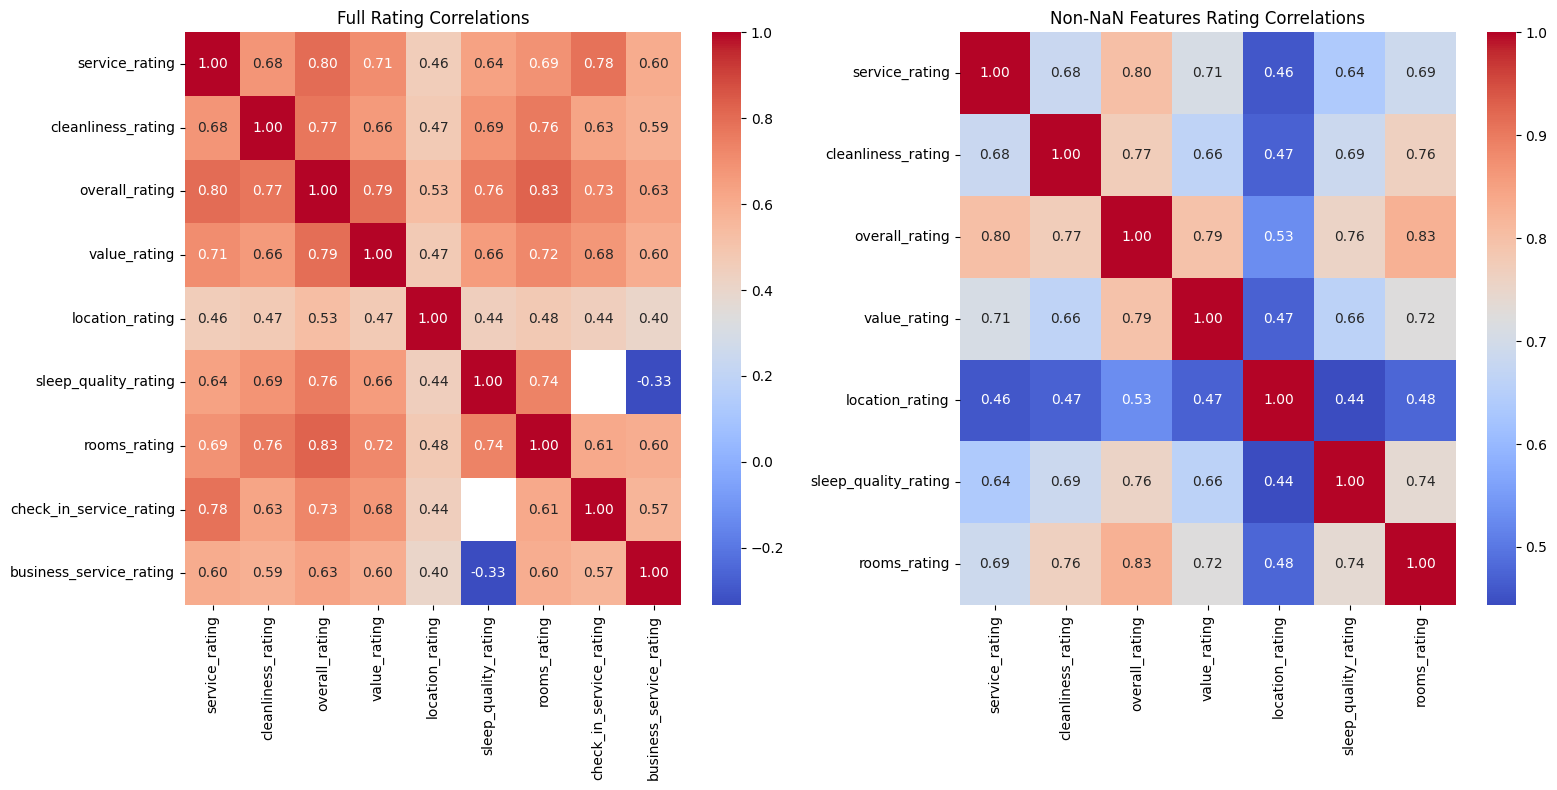

In [20]:
# Get all Rating features
all_column = ['service_rating','cleanliness_rating','overall_rating','value_rating','location_rating','sleep_quality_rating','rooms_rating','check_in_service_rating','business_service_rating']
corr = reviews_df[all_column].corr()

# Get all NONNULL Rating features
nonnull_column = ['service_rating','cleanliness_rating','overall_rating','value_rating','location_rating','sleep_quality_rating','rooms_rating']
corr_non_NaN = reviews_df[nonnull_column].corr()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot correlation heatmap with seaborn
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
sns.heatmap(corr_non_NaN, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])

# Set title for each subplot
axes[0].set_title("Full Rating Correlations")
axes[1].set_title("Non-NaN Features Rating Correlations")

plt.tight_layout()
plt.show()

Key Observations:
* The correlation between some features like overall_rating and rooms_rating are pretty high. The rest of the feature has correlation roughly in 0.44-0.7 range. This shows that the customer gives a quite consistent ratings for many of these columns showing how the highly correlated to one another.
* Sleep quality rating has negative correlation towards business service rating, but considering the low data size, this signal may not be so helpful.


### 2.2. Authors Table

In [21]:
authors_df = dataset['authors']
authors_df.head()

,id,username,num_cities,num_helpful_votes,num_reviews,num_type_reviews,location,alias
0,51C01BDB846DFAA437A89BC08E86BF06,Pnemiller,284.0,883.0,935.0,134.0,"Kutztown, Pennsylvania",
1,CFC0ED785C821E20D403A851C40C5422,texaswillie,221.0,388.0,855.0,112.0,"Dallas, Texas",
2,3F75FA2DE3464A75D56B30470C0EA060,tymetraveler222,217.0,NaN,701.0,100.0,"Bay City, Michigan",
3,FF09B0D2C8126CC12D54B28424BE585D,BrunoldL,167.0,216.0,607.0,118.0,"Klosterneuburg, Austria",
4,03C0F1D9123788CA0A625769BDE3F313,bwco,131.0,NaN,559.0,48.0,"Morris County, NJ",


In [22]:
# Print number of entries
print(f'Number of entries in the authors dataframe: {len(authors_df):,} entries')

Number of entries in the authors dataframe: 75,349 entries


#### 2.2.1 Analyze Columns

In [23]:
authors_df.columns

Index(['id', 'username', 'num_cities', 'num_helpful_votes', 'num_reviews',
       'num_type_reviews', 'location', 'alias'],
      dtype='str')

##### **Numerical**

In [24]:
authors_df.describe()

,num_cities,num_helpful_votes,num_reviews,num_type_reviews
count,54659.000000,58204.000000,75349.000000,44724.000000
mean,11.844893,16.281974,15.659438,12.764265
std,13.250976,32.315139,25.716283,14.381042
min,2.000000,1.000000,1.000000,3.000000
25%,4.000000,2.000000,2.000000,5.000000
50%,8.000000,7.000000,7.000000,8.000000
75%,15.000000,18.000000,20.000000,15.000000
max,284.000000,964.000000,935.000000,275.000000


In [25]:
authors_df['location'].value_counts()

location
                                      4336
New York City, New York                943
London, United Kingdom                 771
Chicago, Illinois                      655
London                                 631
                                      ... 
Bicester                                 1
stewartsville                            1
SAN PEDRO                                1
Vicksburg, MS                            1
Hanford, California, United States       1
Name: count, Length: 19255, dtype: int64

#### 2.2.2. Visualization

##### Distribution of Customer Statistics

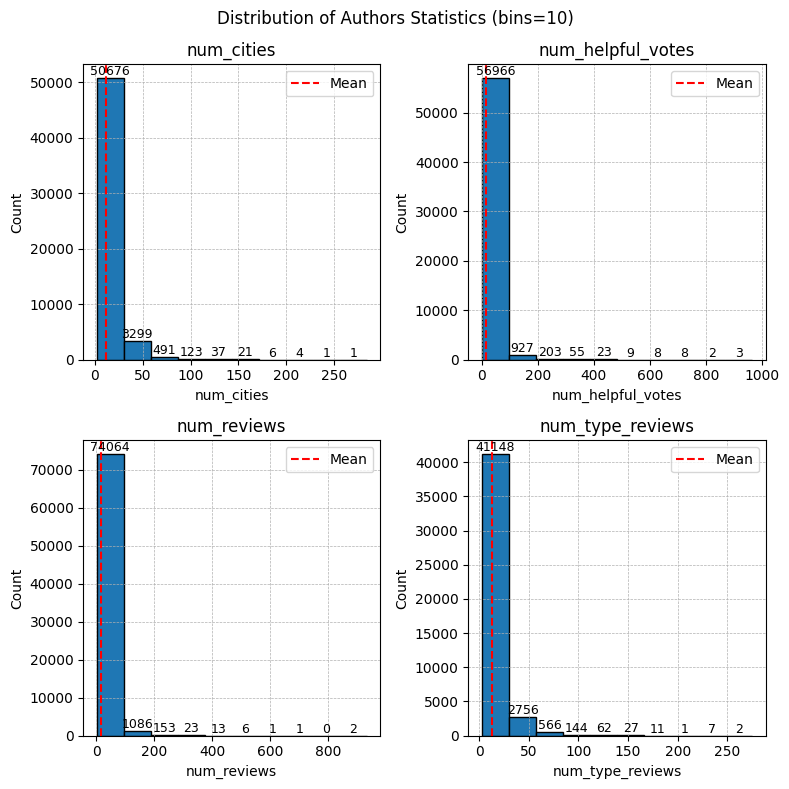

In [26]:
author_column = ['num_cities','num_helpful_votes','num_reviews','num_type_reviews']
bins = 10

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8,8))
ax = ax.flatten()

# Loop for every column
for i, col in enumerate(author_column):
    
    # Get the mean for vertical line
    mean = authors_df[col].mean()
    
    # Replace NaN with string "NaN"
    authors_df_filled = authors_df[col].fillna('NaN').astype(str)
    
    # Do value_counts()
    counts = authors_df_filled.value_counts()
    
    # Plot the histogram with bins
    counts, bin_edges, bars = ax[i].hist(authors_df[col], bins=bins, edgecolor='black')

    # Add count labels on top of each bars
    for count, bar in zip(counts, bars):
        ax[i].text(bar.get_x() + bar.get_width()/2, count, int(count), ha='center', va='bottom', fontsize=9)

    # draw the mean line
    ax[i].axvline(mean, color='red', linestyle='--', label='Mean')
    ax[i].grid(linestyle='--', linewidth=0.5)   # Semi transparent grid
    
    ax[i].legend()
    ax[i].set_title(col)
    ax[i].set_xlabel(col)
    ax[i].set_ylabel('Count')

plt.suptitle(f'Distribution of Authors Statistics (bins={bins})')
plt.tight_layout()
plt.show()

Key Observations:
* All the graphs looks right-skewed, meaning that **the number lies on the lower bin with some entries existing on a higher bin**. Even with large number of bins, the same observation stands. This indicates a low contribution by the author on the 4 aspects of the reviews.
* It's notable that **num_cities and num_type_reviews have a slightly higher mean, but this doesn't change the observation** as well.

##### **Correlation matrix of the features**

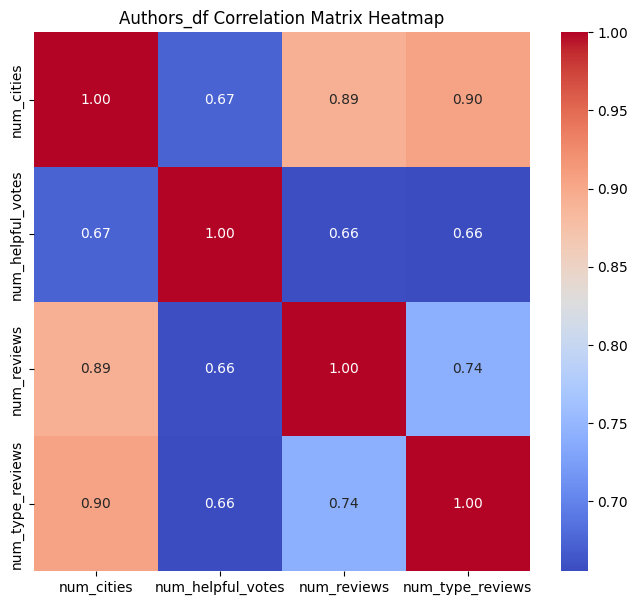

In [27]:
all_column = ['num_cities', 'num_helpful_votes', 'num_reviews', 'num_type_reviews']
corr = authors_df[all_column].corr()

plt.figure(figsize=(8, 7))

# Plot correlation heatmap with seaborn
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Authors_df Correlation Matrix Heatmap')
plt.show()

Key Observations:
* Every feature brings minimum information to the database as the correlation is quite high (0.74-0.9).

### 2.3. Hotels table

In [28]:
hotels_df = dataset['hotels']
hotels_df.head()

,hotel_id,num_reviews,avg_service_rating,avg_cleanliness_rating,avg_overall_rating,avg_value_rating,avg_location_rating,avg_sleep_quality_rating,avg_rooms_rating,avg_check_in_service_rating,avg_business_service_rating
0,214197,1825,2.363836,2.306301,2.261370,2.617534,4.433425,2.595794,2.065205,2.421053,2.265306
1,122005,1774,3.911499,4.221533,3.949267,3.858512,4.665163,4.098581,3.717587,3.623377,3.843137
2,93520,1739,3.522714,3.600920,3.550316,3.557217,4.687752,3.813973,3.456009,2.994012,2.568182
3,93562,1685,4.252819,4.217804,4.077151,4.016617,4.670623,3.936960,3.997033,4.369369,3.757576
4,93618,1647,3.993321,4.101396,3.828780,3.408622,4.602914,4.099425,3.680631,4.134328,3.474359


In [29]:
print(f'Number of entries in the hotels dataframe: {len(hotels_df):,} entries')

Number of entries in the hotels dataframe: 3,380 entries


> The number of hotel in the dataframe is way lower than the number of reviews, but this finding is expected. Actually, the higher the number of reviews compared to the hotel, the better it might be, because then we can dive deeper and obtain more insights for some hotels specifically.

#### 2.3.1 Analyze Columns

In [30]:
hotels_df.columns

Index(['hotel_id', 'num_reviews', 'avg_service_rating',
       'avg_cleanliness_rating', 'avg_overall_rating', 'avg_value_rating',
       'avg_location_rating', 'avg_sleep_quality_rating', 'avg_rooms_rating',
       'avg_check_in_service_rating', 'avg_business_service_rating'],
      dtype='str')

In [31]:
hotels_df.describe()

,num_reviews,avg_service_rating,avg_cleanliness_rating,avg_overall_rating,avg_value_rating,avg_location_rating,avg_sleep_quality_rating,avg_rooms_rating,avg_check_in_service_rating,avg_business_service_rating
count,3380.000000,3380.000000,3380.000000,3380.000000,3380.000000,3380.000000,3347.000000,3380.000000,2503.000000,2384.000000
mean,148.263609,3.848832,3.903125,3.654028,3.750639,4.056105,3.787525,3.670522,3.825460,3.560001
std,218.972431,0.731526,0.806769,0.785323,0.664928,0.649463,0.738412,0.788405,0.872021,0.940848
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,23.000000,3.571200,3.600000,3.332237,3.500000,3.752552,3.500000,3.299899,3.451613,3.000000
50%,60.500000,4.030892,4.138090,3.833333,3.884615,4.191622,3.987342,3.844960,4.000000,3.687500
75%,184.000000,4.343800,4.468659,4.200505,4.187889,4.533333,4.293641,4.227553,4.444444,4.200000
max,1825.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


#### 2.3.2 Visualization

##### **Distribution of Number of Reviews**

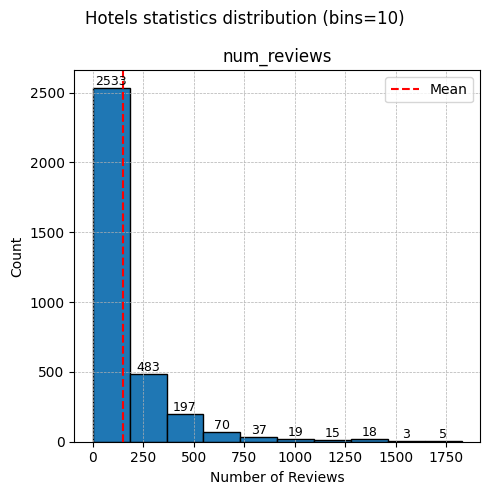

In [32]:
hotel_column = ['num_reviews']
bins = 10

plt.figure(figsize=(5,5))

# Get the mean for vertical line
mean = hotels_df['num_reviews'].mean()

# Replace NaN with string "NaN"
hotels_df_filled = hotels_df['num_reviews'].fillna('NaN').astype(str)

# Do value_counts()
counts = hotels_df_filled.value_counts()

# Plot the histogram with bins
counts, bin_edges, bars = plt.hist(hotels_df['num_reviews'], bins=bins, edgecolor='black')

# Add count labels on top of bars
for count, bar in zip(counts, bars):
    plt.text(bar.get_x() + bar.get_width()/2, count, int(count), ha='center', va='bottom', fontsize=9)

# draw the mean line
plt.axvline(mean, color='red', linestyle='--', label='Mean')
plt.grid(linestyle='--', linewidth=0.5)

plt.legend()
plt.title('num_reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Count')

plt.suptitle(f'Hotels statistics distribution (bins={bins})')
plt.tight_layout()
plt.show()

Key observations:
* The number of hotel receiving large number of reviews is not bad, but the bar is still right-skewed meaning that it would be way more optimal if all hotels receives equal amoung ot reviews to have a balanced data, although this is hard to achieve in real-life scenario.

##### **Distribution of Reviews per Star Rating**

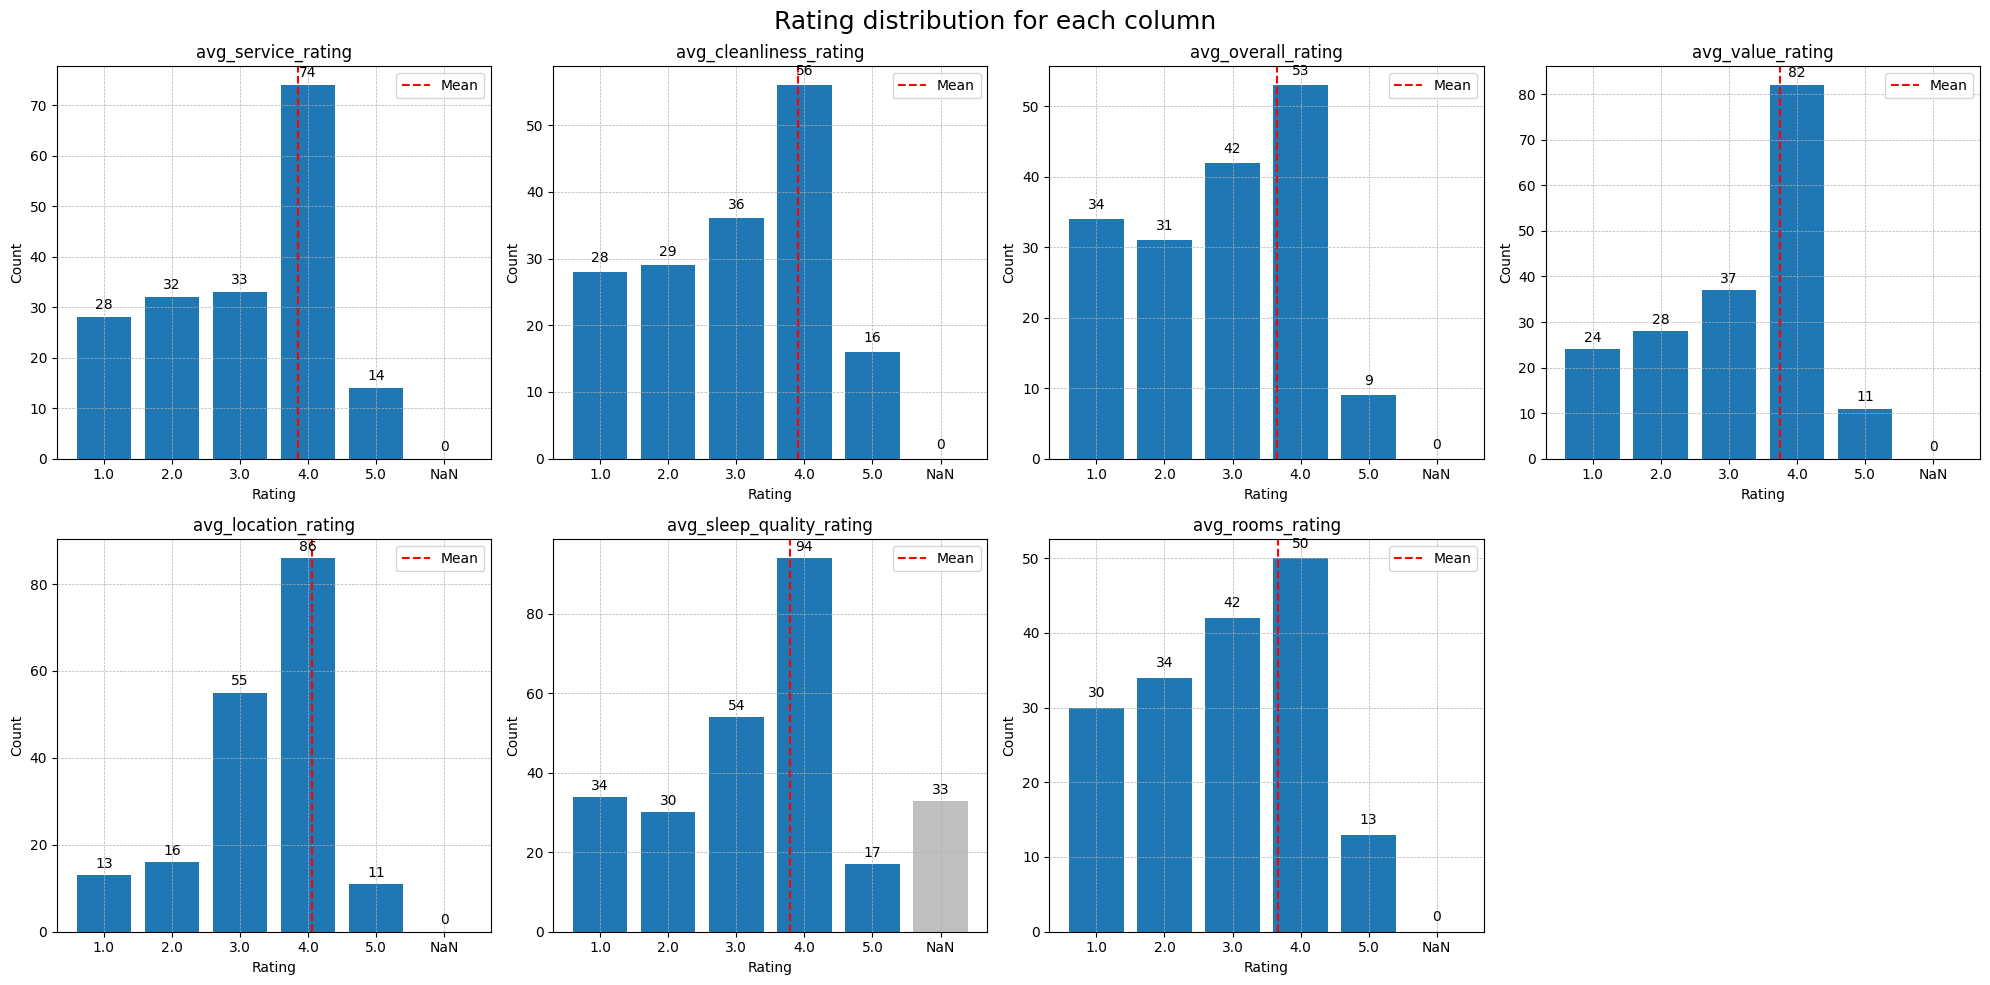

In [33]:
hotel_column = ['avg_service_rating','avg_cleanliness_rating','avg_overall_rating','avg_value_rating','avg_location_rating','avg_sleep_quality_rating','avg_rooms_rating',]

# Prepare subplot
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(20,10))
ax = ax.flatten()

# Loop for each column
for i, col in enumerate(hotel_column):
    
    # Get the mean for vertical line
    mean = hotels_df[col].mean()
    
    # Replace NaN with string "NaN"
    hotels_df_filled = hotels_df[col].fillna('NaN').astype(str)
    
    # Do value_counts()
    counts = hotels_df_filled.value_counts()
    
    # Reindex so that we can show the NaN values as well
    counts = counts.reindex(['1.0', '2.0', '3.0', '4.0', '5.0', 'NaN'], fill_value=0)
    colors = ['C0'] * 5 + ['gray']
    
    # Plot the bar in the subplot
    bars = ax[i].bar(counts.index, counts.values, color=colors)
    
    # Add counts on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax[i].text(bar.get_x() + bar.get_width()/2, height + 1, str(height), ha='center', va='bottom', fontsize=10)
    
    # Set the alpha of the NaN to semi-transparent
    bars[-1].set_alpha(0.5)
    
    # Only draw mean if numeric, ignore NaN
    if not np.isnan(mean):
        # Find position on x-axis
        mean_pos = mean - 1  # Subtract position by 1
        ax[i].axvline(mean_pos, color='red', linestyle='--', label='Mean')
        ax[i].legend()
        
    ax[i].set_title(f'{col}')
    ax[i].set_xlabel('Rating')
    ax[i].set_ylabel('Count')
    ax[i].grid(linestyle = '--', linewidth = 0.5)

# Hide the last subplot
ax[-1].axis('off')

plt.suptitle('Rating distribution for each column', fontsize=18)
plt.tight_layout()
plt.show()

Key Observations:
* Most hotels don't struggle with their location rating as the mean and count for high star rating looks good.
* On the rest of the columns, although rating of the hotels averages at 4 but the cummulative of the ratin 103 is actually significant, showing how major amount of hotels still receives bad scores over this rating aspect.

##### **Correlation matrix of the features**

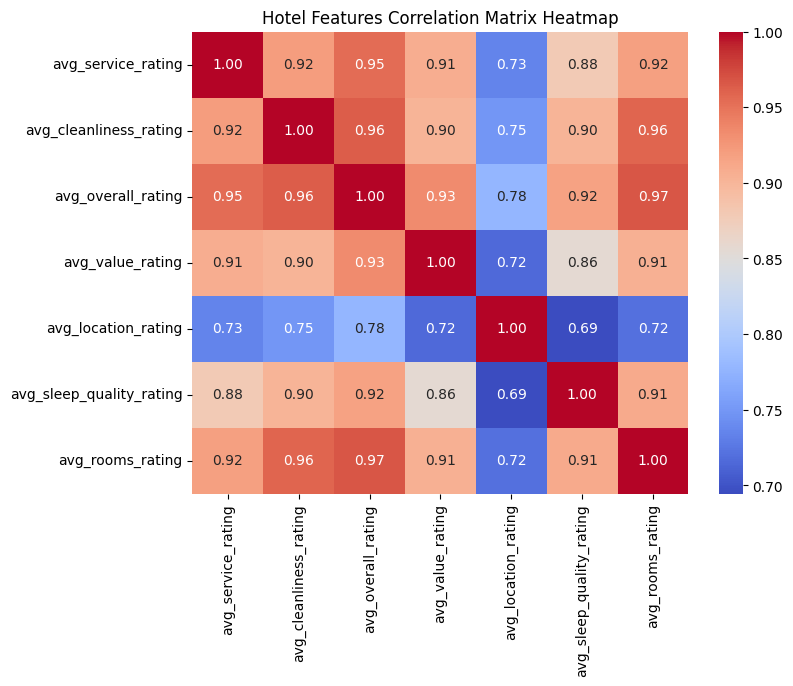

In [34]:

all_column = ['avg_service_rating','avg_cleanliness_rating','avg_overall_rating','avg_value_rating','avg_location_rating','avg_sleep_quality_rating','avg_rooms_rating']
corr = hotels_df[all_column].corr()

plt.figure(figsize=(8, 6))

# Plot corelation heatmap with seaborn
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Hotel Features Correlation Matrix Heatmap')
plt.show()

Key Observations:
* There is not much observation for this part as these columsn are just an aggregation of all the reviews, but now the number might be more realiable as the weight for each hotel are now equal. Even so, the findings will be very identical as the previous correlation heatmap.


---

## 3. Feature Engineering

### 3.1. **review_frequency** (authors_df)

Whether an author frequently write reviews compared to the median of all authors.

In [35]:
authors_df.head(2)

,id,username,num_cities,num_helpful_votes,num_reviews,num_type_reviews,location,alias
0,51C01BDB846DFAA437A89BC08E86BF06,Pnemiller,284.0,883.0,935.0,134.0,"Kutztown, Pennsylvania",
1,CFC0ED785C821E20D403A851C40C5422,texaswillie,221.0,388.0,855.0,112.0,"Dallas, Texas",


We need to check the skewness of the data before doing the threshold, therefore let's visualize the feature

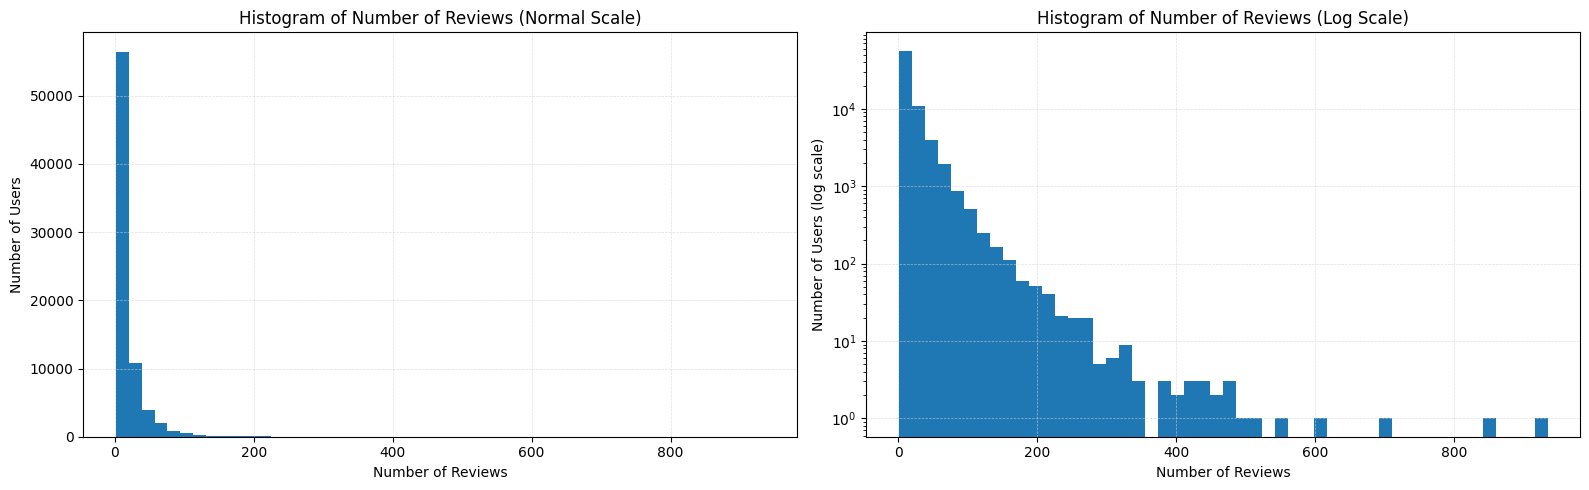

In [36]:
# Get the value counts of num_reviews
authors_df['num_reviews'].value_counts()

# Create a figure with 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16,5))

# Normal scale histogram
axes[0].hist(authors_df['num_reviews'], bins=50)
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Histogram of Number of Reviews (Normal Scale)')
axes[0].grid(True, color='lightgray', linestyle='--', linewidth=0.5, alpha=0.7)

# Log scale histogram
axes[1].hist(authors_df['num_reviews'], bins=50, log=True)
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('Number of Users (log scale)')
axes[1].set_title('Histogram of Number of Reviews (Log Scale)')
axes[1].grid(True, color='lightgray', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()


The heavy skewness makes it hard to use simple thresholding with mean, std, or median. Our approach will use the quantile based categorization so that we have a balanced category.

In [37]:
# Set the quantile
q1 = authors_df['num_reviews'].quantile(0.33)
q2 = authors_df['num_reviews'].quantile(0.66)

print('=' * 40)
print('category')
print('=' * 40)
print(f'range from 0 - {q1} ===> Low')
print(f'range from {q1} - {q2} ===> Medium')
print(f'range from {q2} - infinity ===> High')
print('=' * 40)

def categorize_reviews(n):
    if n <= q1:
        return 'low'
    elif n <= q2:
        return 'medium'
    else:
        return 'high'

authors_df['review_frequency'] = authors_df['num_reviews'].apply(categorize_reviews)

category
range from 0 - 3.0 ===> Low
range from 3.0 - 13.0 ===> Medium
range from 13.0 - infinity ===> High


Now we print the total for each frequency.

In [38]:
for freq in ['low', 'medium', 'high']:
    print(f"{freq.upper()} frequency total: {len(authors_df[authors_df['review_frequency'] == freq]):,}")

LOW frequency total: 28,732
MEDIUM frequency total: 21,495
HIGH frequency total: 25,122


In [39]:
# IF USING MEAN STD OR MEDIAN
freq_df = authors_df.copy()

mean = freq_df['num_reviews'].mean()
median = freq_df['num_reviews'].median()
std = freq_df['num_reviews'].std()

freq_df['freq_mean'] = freq_df['num_reviews'] > mean
freq_df['freq_mean_std'] = freq_df['num_reviews'] > (mean + std)
freq_df['freq_median'] = freq_df['num_reviews'] > median

for freq in ['freq_mean', 'freq_mean_std', 'freq_median']:
    print(f'\n{freq}')
    print(f'frequent: {freq_df[freq].sum():,}')
    print(f'not frequent: {len(freq_df) - (freq_df[freq].sum()):,}')


freq_mean
frequent: 22,493
not frequent: 52,856

freq_mean_std
frequent: 7,252
not frequent: 68,097

freq_median
frequent: 35,274
not frequent: 40,075


Using the mean and std will make the class very unstable.

Using median might be a good choice, but it will only allow binary categorization instead of multi level category.

In [40]:
# Print 10 random samples
authors_df.sample(10)

,id,username,num_cities,num_helpful_votes,num_reviews,num_type_reviews,location,alias,review_frequency
54783,7BB56805408D0A6921B26D28A3E29920,tiffany j,NaN,2.0,2.0,NaN,"Cincinnati, Ohio",,low
58836,00AB69D0D86013C7B1175C20EFBE0245,Carol C,NaN,NaN,1.0,NaN,"Modesto, California",,low
49984,7BDBFD29BAA86F943592A281D3538E95,Mike O,2.0,2.0,3.0,NaN,"Chicago, Illinois",,low
69988,3EC7A08BFB67CEDBAE10A40C00B0031C,martha m,NaN,2.0,1.0,NaN,"Stonington, Connecticut",,low
23847,F65E0F82FC392FDFFD70453EF38C3355,johndoe-ta,9.0,5.0,14.0,8.0,"San Diego, California",,high
1040,7D27F97D7562DFF7A3BC853E72577703,redanteater,71.0,81.0,102.0,75.0,"Los Angeles, California",,high
32875,4EE72A84DC3D8F7CD404E9945D9EEE38,Catescatescates,3.0,1.0,9.0,NaN,"Chicago, Illinois, United States",,medium
26120,145DD40AE1CF6CE6B5E82AACE50BCEC8,TXTraveler424,13.0,31.0,13.0,13.0,"Austin, Texas",,medium
30747,2F016A568E124FDDA65D479419078FD8,Conikazi8,6.0,4.0,10.0,6.0,Maryland,,medium
50552,925125060868412CBE2940B908484166,bluetravels8,3.0,2.0,3.0,3.0,Vancouver,,low


For the visualization

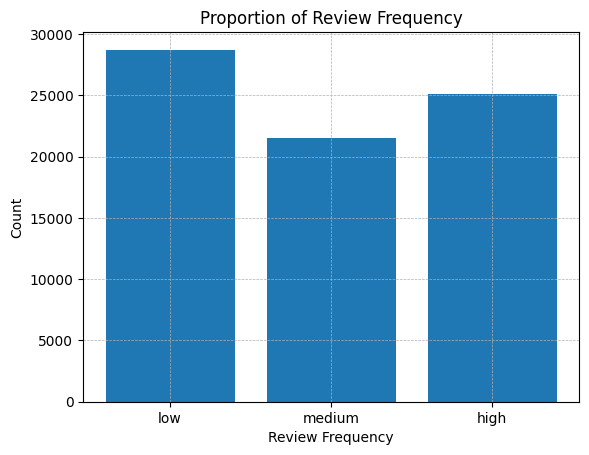

In [41]:
freq_counts = authors_df['review_frequency'].value_counts()

order = ['low', 'medium', 'high']
freq_counts = freq_counts.reindex(order, fill_value=0)

# Plot
plt.grid(linestyle='--', linewidth=0.5)
plt.bar(freq_counts.index, freq_counts.values)
plt.xlabel("Review Frequency")
plt.ylabel("Count")
plt.title("Proportion of Review Frequency")
plt.show()

### 3.2. **helpful_votes_ratio** (authors_df)

Ratio of how many helpful reviews produced by the user compared to the number of reviews published

* formula: number of helpful votes / number of reviews

In [42]:
# Fill NaN to prevent error
authors_df[['num_helpful_votes', 'num_reviews']] = authors_df[['num_helpful_votes', 'num_reviews']].fillna(0)

# Check validity if helpful notes is larger than num_reviews (invalid)
authors_df['num_helpful_votes'] = authors_df[['num_helpful_votes', 'num_reviews']].min(axis=1)

authors_df['helpful_votes_ratio'] = np.where(
    (authors_df['num_helpful_votes'] == 0) | (authors_df['num_reviews'] == 0), 0, authors_df['num_helpful_votes'] / authors_df['num_reviews']
)

authors_df.head(2)

,id,username,num_cities,num_helpful_votes,num_reviews,num_type_reviews,location,alias,review_frequency,helpful_votes_ratio
0,51C01BDB846DFAA437A89BC08E86BF06,Pnemiller,284.0,883.0,935.0,134.0,"Kutztown, Pennsylvania",,high,0.944385
1,CFC0ED785C821E20D403A851C40C5422,texaswillie,221.0,388.0,855.0,112.0,"Dallas, Texas",,high,0.453801


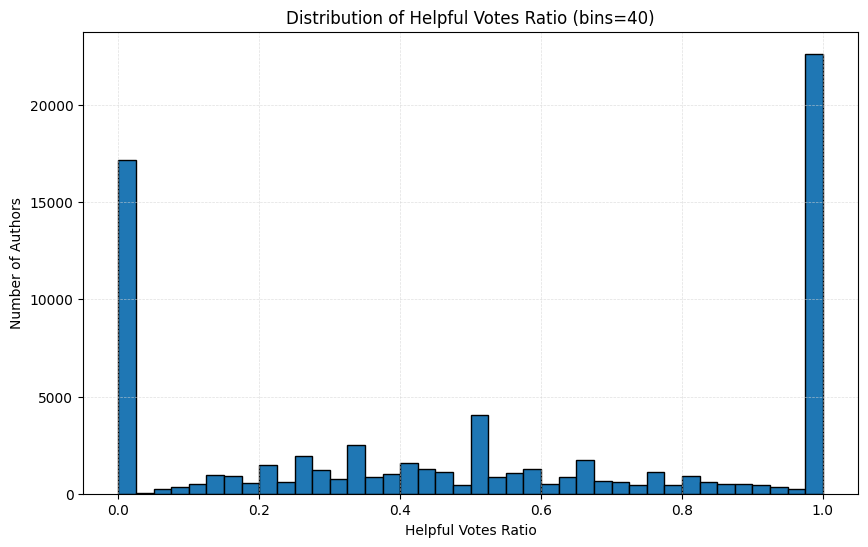

In [43]:
bins = 40

plt.figure(figsize=(10,6))

plt.hist(authors_df['helpful_votes_ratio'], bins=bins, edgecolor='black')

plt.grid(True, color='lightgray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.title(f'Distribution of Helpful Votes Ratio (bins={bins})')
plt.xlabel('Helpful Votes Ratio')
plt.ylabel('Number of Authors')

plt.show()

### 3.3. **avg_stars_given** authors_df

Average of stars given by a user in all their reviews

* formula: mean of all stars given in reviews dataframe.

In [44]:
reviews_df.head(2)

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id,reviews_days_since_stay
0,“Daaaaaa Bears!”,I recently stayed at W Chicago Lakeshore and o...,2012-11-01,225108,0,2012-11-19,145753174,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,714F49AC057498AEA304343E569A2A03,18 days
1,“Would go back in a heartbeat- Location Locati...,We booked this hotel after out initial travel ...,2010-09-01,122005,1,2010-10-02,81870377,0,3.0,5.0,4.0,5.0,5.0,5.0,3.0,NaN,NaN,74C5A4455E1AAE46B0C54FC6CCBD7033,31 days


In [45]:
stars_df = reviews_df[['review_id', 'author_id', 'service_rating', 'cleanliness_rating', 'overall_rating', 	'value_rating', 'location_rating', 'sleep_quality_rating', 'rooms_rating', 'check_in_service_rating', 'business_service_rating']].copy()
stars_df['author_id'].isna().sum()

stars_df


,review_id,author_id,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating
0,145753174,714F49AC057498AEA304343E569A2A03,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN
1,81870377,74C5A4455E1AAE46B0C54FC6CCBD7033,3.0,5.0,4.0,5.0,5.0,5.0,3.0,NaN,NaN
2,33732815,CC2C523A197E7024A07BE083E1573E75,5.0,4.0,4.0,4.0,4.0,NaN,4.0,NaN,NaN
3,32773886,D879DE1351CB445AEF3B247EF25CFC00,3.0,4.0,4.0,4.0,4.0,NaN,3.0,NaN,NaN
4,38157829,404B9AF8897A742142CEBF4F0596EF5E,4.0,5.0,4.0,3.0,3.0,NaN,3.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
79995,50826156,309A277A5D221634DA28090144520A10,4.0,2.0,3.0,2.0,4.0,NaN,3.0,NaN,NaN
79996,123858080,8C7A26020CD00F6C88B7A2537AB0F3BE,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN
79997,118987846,0AAFAB9A0D356BCF6E56DCDA6ECD73D2,5.0,5.0,4.0,3.0,5.0,3.0,4.0,NaN,NaN
79998,109895397,220F304A84F86A2E5AF856F270C775D5,5.0,5.0,5.0,4.0,5.0,5.0,4.0,NaN,NaN


In [46]:
rating_cols = [
    'service_rating', 'cleanliness_rating', 'overall_rating', 'value_rating',
    'location_rating', 'sleep_quality_rating', 'rooms_rating', 'check_in_service_rating',
    'business_service_rating'
]

stars_df = stars_df.groupby('author_id')[rating_cols].mean()
stars_df['final_overall_avg'] = stars_df.mean(axis=1)

# Reset index and rename to align with authors_df
stars_df.reset_index(inplace=True)
stars_df.rename(columns={'author_id': 'id'}, inplace=True)
stars_df.sample(5)

,id,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,final_overall_avg
27712,5DEFF8FA09B2F84A002E6DFA228A2015,4.0,4.0,5.0,4.0,4.0,4.0,5.0,NaN,NaN,4.285714
69459,EC18CDF29FF6B600F073CEAAFBE28703,4.0,4.0,4.0,5.0,5.0,5.0,5.0,NaN,NaN,4.571429
530,01B131B5B2ECDDAB4CBA30BF02465549,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,5.000000
222,00B7B67701760CD75289794D8696F030,4.0,4.0,4.0,5.0,4.0,5.0,4.0,NaN,NaN,4.285714
44150,960FD2F4B3DB480E0579FB29CC17F4B3,3.0,3.0,3.0,4.0,3.0,4.0,3.0,NaN,NaN,3.285714


Merge the stars_df back to authors_df

In [47]:
authors_df = authors_df.merge(stars_df, on='id', how='left')
authors_df.sample(10)

,id,username,num_cities,num_helpful_votes,num_reviews,num_type_reviews,location,alias,review_frequency,helpful_votes_ratio,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,final_overall_avg
15931,952EED62F86E03F36A2DE6DD3FF3F150,garratys,18.0,23.0,23.0,15.0,"Washington DC, District of Columbia",,high,1.000000,5.0,4.0,5.0,4.0,5.0,NaN,4.0,NaN,NaN,4.500000
39435,78E0DD2190A697B6AAAE1F029FD9452A,J00stC,NaN,1.0,6.0,NaN,"Belgium, Wisconsin",,medium,0.166667,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,5.000000
23881,593A731B52265A23F9D712D144A62D7D,Nanci P,5.0,1.0,14.0,4.0,"Auburn, Washington",,high,0.071429,4.0,4.0,3.0,3.0,3.0,4.0,3.0,NaN,NaN,3.428571
69201,8E1F331B2FC5AA5B1FD0B552169F073C,between_lives12,NaN,0.0,1.0,NaN,"Racine, WI",,low,0.000000,5.0,3.0,3.0,3.0,4.0,3.0,4.0,NaN,NaN,3.571429
43199,CE68B9967FBC4210E4F34758966CBD05,mesquitemachine,3.0,4.0,4.0,4.0,Dallas,,medium,1.000000,5.0,5.0,4.0,3.0,4.0,NaN,4.0,5.0,NaN,4.285714
31721,08E9174244ED0193D98E3E6F4AACA857,Torsten32655,9.0,0.0,9.0,9.0,"Los Angeles, California",,medium,0.000000,4.0,4.0,5.0,4.0,4.0,3.0,5.0,NaN,NaN,4.142857
36459,F6EB7B573A9DD022E0A4F065B7ED0A45,RickChicago_IL,6.0,2.0,7.0,5.0,"Chicago, IL",,medium,0.285714,3.0,4.0,4.0,5.0,3.0,NaN,4.0,NaN,NaN,3.833333
33798,0D9E9871A1E1EDDB179FE9A42C9078B2,AllieKY,6.0,5.0,8.0,3.0,Kentucky,,medium,0.625000,5.0,5.0,5.0,4.0,5.0,5.0,5.0,NaN,NaN,4.857143
3879,FB68926B57A24F3DB25082847FB3FB05,kahala25,16.0,44.0,59.0,27.0,神戸,,high,0.745763,4.0,4.0,4.0,3.0,5.0,4.0,4.0,NaN,NaN,4.000000
67725,859B4A514E921A6467F4A8C9D8AC01DF,cincin123,NaN,1.0,1.0,NaN,"Wildwood, New Jersey",,low,1.000000,5.0,5.0,5.0,5.0,3.0,4.0,5.0,NaN,NaN,4.571429


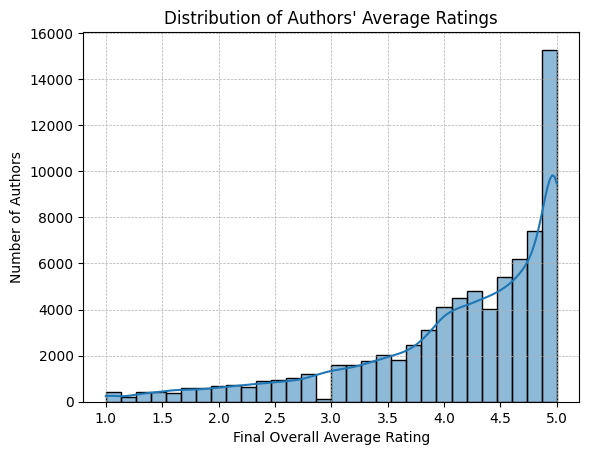

In [48]:
sns.histplot(authors_df['final_overall_avg'], bins=30, kde=True)
plt.xlabel("Final Overall Average Rating")
plt.ylabel("Number of Authors")
plt.title("Distribution of Authors' Average Ratings")
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

You can see the tendencies of user giving 5 stars by default is very high. This proves that the authors will most likely give 5 stars ratings. Although this shows that the data is not skewed towards negative reviews, but having too much 5 stars ratings average can also add up complexity due to certain bias of the authors.

### 3.4. **ratings_variance** (hotels_df)

Indicate whether a hotel consistently receives certain number of starts or not.

* formula: average of squared differences between each data point and the mean

In [49]:
reviews_df.head(2)

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id,reviews_days_since_stay
0,“Daaaaaa Bears!”,I recently stayed at W Chicago Lakeshore and o...,2012-11-01,225108,0,2012-11-19,145753174,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,714F49AC057498AEA304343E569A2A03,18 days
1,“Would go back in a heartbeat- Location Locati...,We booked this hotel after out initial travel ...,2010-09-01,122005,1,2010-10-02,81870377,0,3.0,5.0,4.0,5.0,5.0,5.0,3.0,NaN,NaN,74C5A4455E1AAE46B0C54FC6CCBD7033,31 days


In [50]:
variance_df = reviews_df.copy()

rating_columns = [
    'service_rating', 'cleanliness_rating', 'overall_rating', 
    'value_rating', 'location_rating', 'sleep_quality_rating', 
    'rooms_rating', 'check_in_service_rating', 'business_service_rating'
]

variance_df = variance_df.groupby('hotel_id')[rating_columns].var(ddof=0)

variance_df = variance_df.reset_index()

variance_df = variance_df.rename(columns={col: f"{col}_variance" for col in variance_df.columns if col != 'hotel_id'})

In [51]:
hotels_df = hotels_df.merge(variance_df, on='hotel_id', how='left')
hotels_df.sample(10)

,hotel_id,num_reviews,avg_service_rating,avg_cleanliness_rating,avg_overall_rating,avg_value_rating,avg_location_rating,avg_sleep_quality_rating,avg_rooms_rating,avg_check_in_service_rating,avg_business_service_rating,service_rating_variance,cleanliness_rating_variance,overall_rating_variance,value_rating_variance,location_rating_variance,sleep_quality_rating_variance,rooms_rating_variance,check_in_service_rating_variance,business_service_rating_variance
1989,223230,42,4.428571,4.666667,4.500000,4.500000,4.452381,4.400000,4.666667,4.500000,4.500000,0.187500,0.000000,0.250000,0.250000,0.187500,0.250000,0.187500,0.00,0.0000
2662,100621,19,3.526316,3.578947,3.263158,3.210526,3.684211,3.416667,3.052632,NaN,NaN,1.428571,1.346939,1.836735,2.530612,1.061224,1.200000,3.061224,NaN,NaN
2621,240526,21,3.761905,3.476190,3.238095,3.666667,3.095238,4.142857,3.476190,2.500000,3.333333,2.560000,2.560000,2.560000,0.800000,1.040000,0.666667,2.800000,0.00,NaN
3339,260923,2,2.000000,2.000000,1.500000,2.500000,3.500000,2.500000,1.500000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
3275,247110,4,1.750000,2.250000,1.750000,1.500000,1.500000,3.000000,2.000000,2.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
1524,81667,76,3.921053,4.026316,3.736842,3.921053,4.407895,4.000000,3.750000,4.000000,4.333333,1.138889,0.888889,1.138889,0.666667,0.555556,0.888889,1.000000,0.00,NaN
1129,94122,129,4.108527,4.139535,3.899225,3.922481,3.922481,4.074468,4.085271,4.000000,2.888889,1.909091,1.016529,1.266529,1.448347,0.679752,1.976331,1.016529,0.00,1.0000
744,87656,210,3.676190,3.604762,3.342857,3.671429,4.771429,3.620690,3.004762,3.040000,2.181818,1.771542,1.467687,1.644558,1.771542,0.832766,1.575255,1.551020,2.25,1.6875
543,98679,282,3.936170,3.992908,3.620567,3.436170,3.865248,3.673469,3.613475,3.807692,3.111111,1.243802,1.090909,0.969008,1.444215,1.389979,1.697979,1.162707,0.00,NaN
2899,98628,13,3.769231,3.923077,3.307692,3.076923,2.846154,3.909091,3.461538,NaN,NaN,0.888889,0.888889,0.888889,2.000000,0.222222,0.888889,0.666667,NaN,NaN


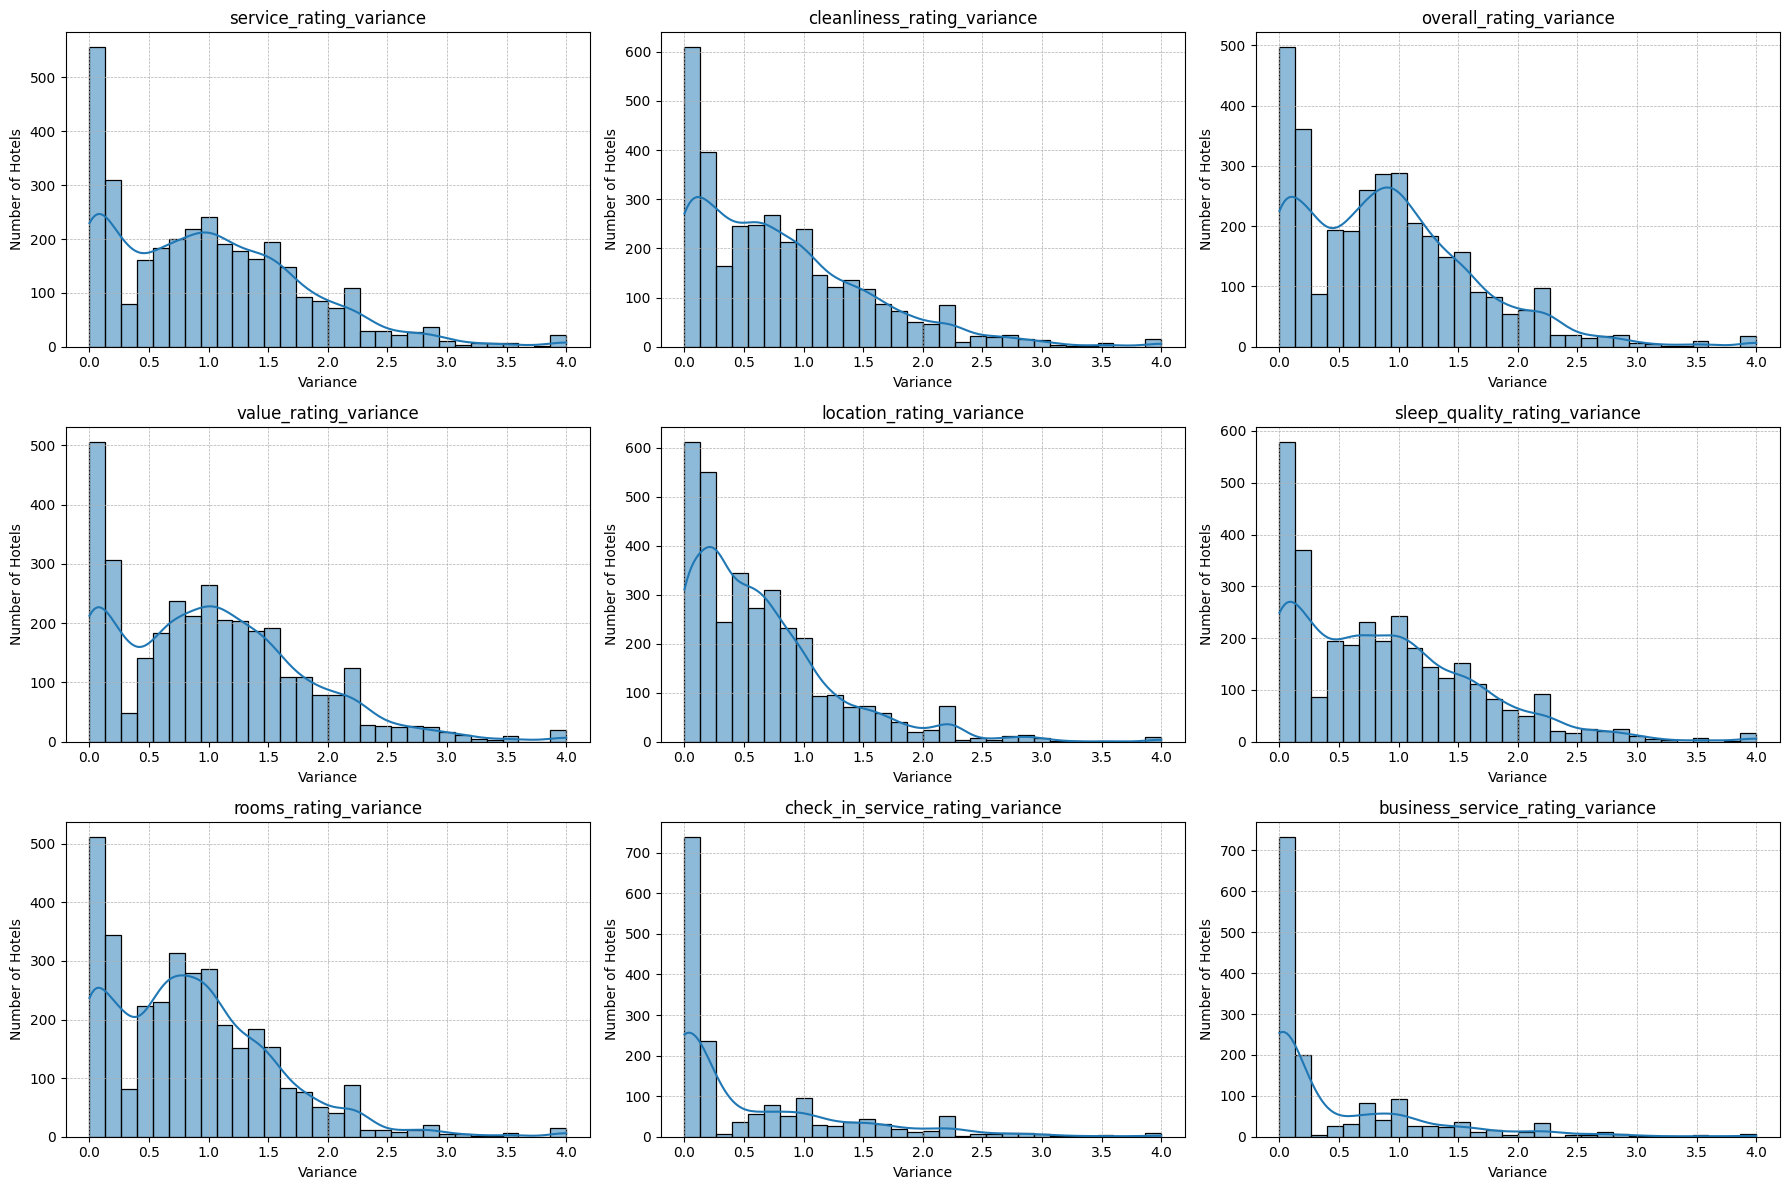

In [52]:
variance_cols = [col for col in hotels_df.columns if 'variance' in col]

num_cols = 3
num_rows = (len(variance_cols) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows*4))
axes = axes.flatten()

for i, col in enumerate(variance_cols):
    sns.histplot(hotels_df[col], bins=30, kde=True, ax=axes[i])
    axes[i].grid(linestyle='--', linewidth=0.5)
    axes[i].set_title(col)
    axes[i].set_xlabel("Variance")
    axes[i].set_ylabel("Number of Hotels")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Observations:
* Based on the graph we can see that the variance lies within 0 and 1, this is still fine althoug we expect the peak to be exactly at 0.
* You can see that the graph has increasing variance on the tail part.
* This finding means that most authors consistently give similar ratings which makes the variance low, so they all produce similar agreement on the ratings. But some users are of course very subjective and can rate differenly even though majority of the other authors rates good, which increases the variance on the tail part.
* The most consistent rating can only be seen on location rating and cleanliness.

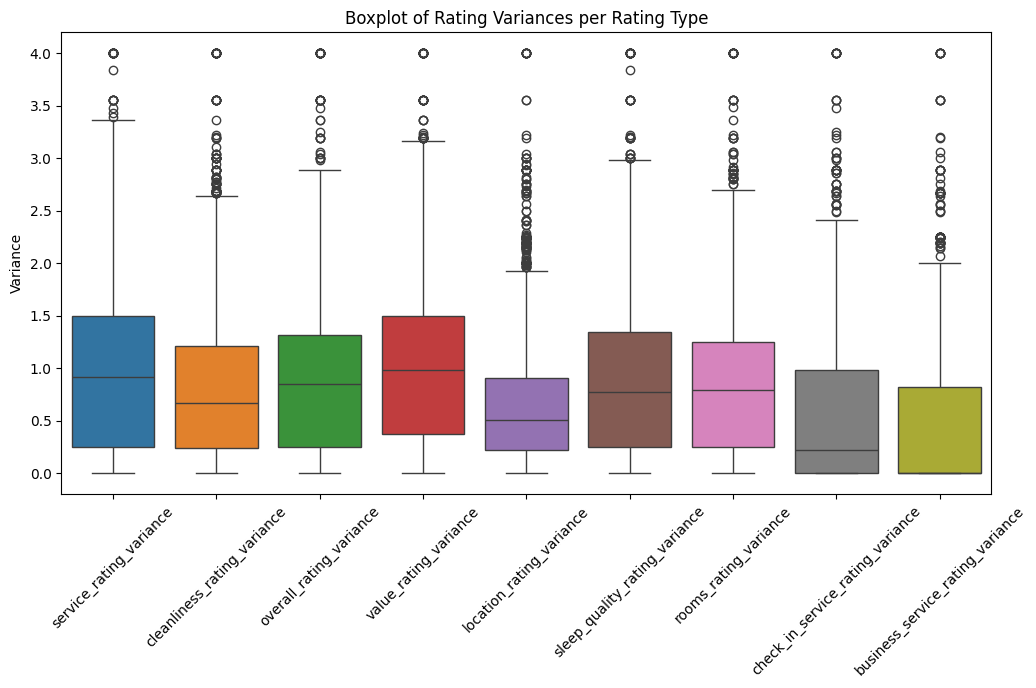

In [53]:
plt.figure(figsize=(12,6))

sns.boxplot(data=hotels_df[variance_cols])

plt.xticks(rotation=45)
plt.ylabel("Variance")
plt.title("Boxplot of Rating Variances per Rating Type")
plt.show()


Observations:
* Similar observations can be seen here, but more detail about the quartile, min, max, and even outliers are now visible.
* Still location rating has the lower variance (without consideting check in and business service rating) that prove its consistency in receiving the rating.

---

## 4. (Extra exploration) Analytics by Business Questions

### **a. How does the hotel rating differ by location?**

ALERT!!! Location is not in the hotels_df

### **b. Best and worst hotels from each service category?**

In [54]:
# Generated by chatGPT but will be reviewed and modified in a few moment
def analyze_hotels_per_category_subplots(df, min_reviews=1):

    df_filtered = df[df['num_reviews'] >= min_reviews].copy()
    
    rating_cols = [c for c in df.columns if c.startswith('avg_') and 'rating' in c]
    
    n_cols = 2  # number of columns in subplot grid
    n_rows = (len(rating_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows*4))
    axes = axes.flatten()
    
    for i, col in enumerate(rating_cols):
        var_col = col.replace('avg_', '') + '_variance'
        if var_col not in df_filtered.columns:
            df_filtered[var_col] = 0
        
        # Sort and pick top 3 + bottom 3
        df_sorted = df_filtered.sort_values(
            by=[col, 'num_reviews', var_col],
            ascending=[False, False, True]
        )
        best_3 = df_sorted.head(3)
        worst_3 = df_sorted.tail(3)
        combined = pd.concat([best_3, worst_3])
        
        # X labels: hotel_id (num_reviews)
        x_labels = [f"{hid}\n({rev})" for hid, rev in zip(combined['hotel_id'], combined['num_reviews'])]
        
        combined['hue'] = ['Best']*3 + ['Worst']*3
        
        sns.barplot(
            x=x_labels,
            y=combined[col].values,
            hue=combined['hue'],        # assign hue
            dodge=False,                 # prevents side-by-side bars
            palette={'Best': 'green', 'Worst': 'red'},
            ax=axes[i]
        )
        axes[i].legend_.remove()
        
        axes[i].set_title(f"{col}")
        axes[i].set_ylabel("Rating")
        axes[i].set_xlabel("Hotel ID (num_reviews)")
        axes[i].grid(True, color='lightgray', linestyle='--', linewidth=0.5, alpha=0.7)
    
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)  # adjust to make space for suptitle
    plt.suptitle("Best & Worst performer by each category", fontsize=16)
    plt.show()


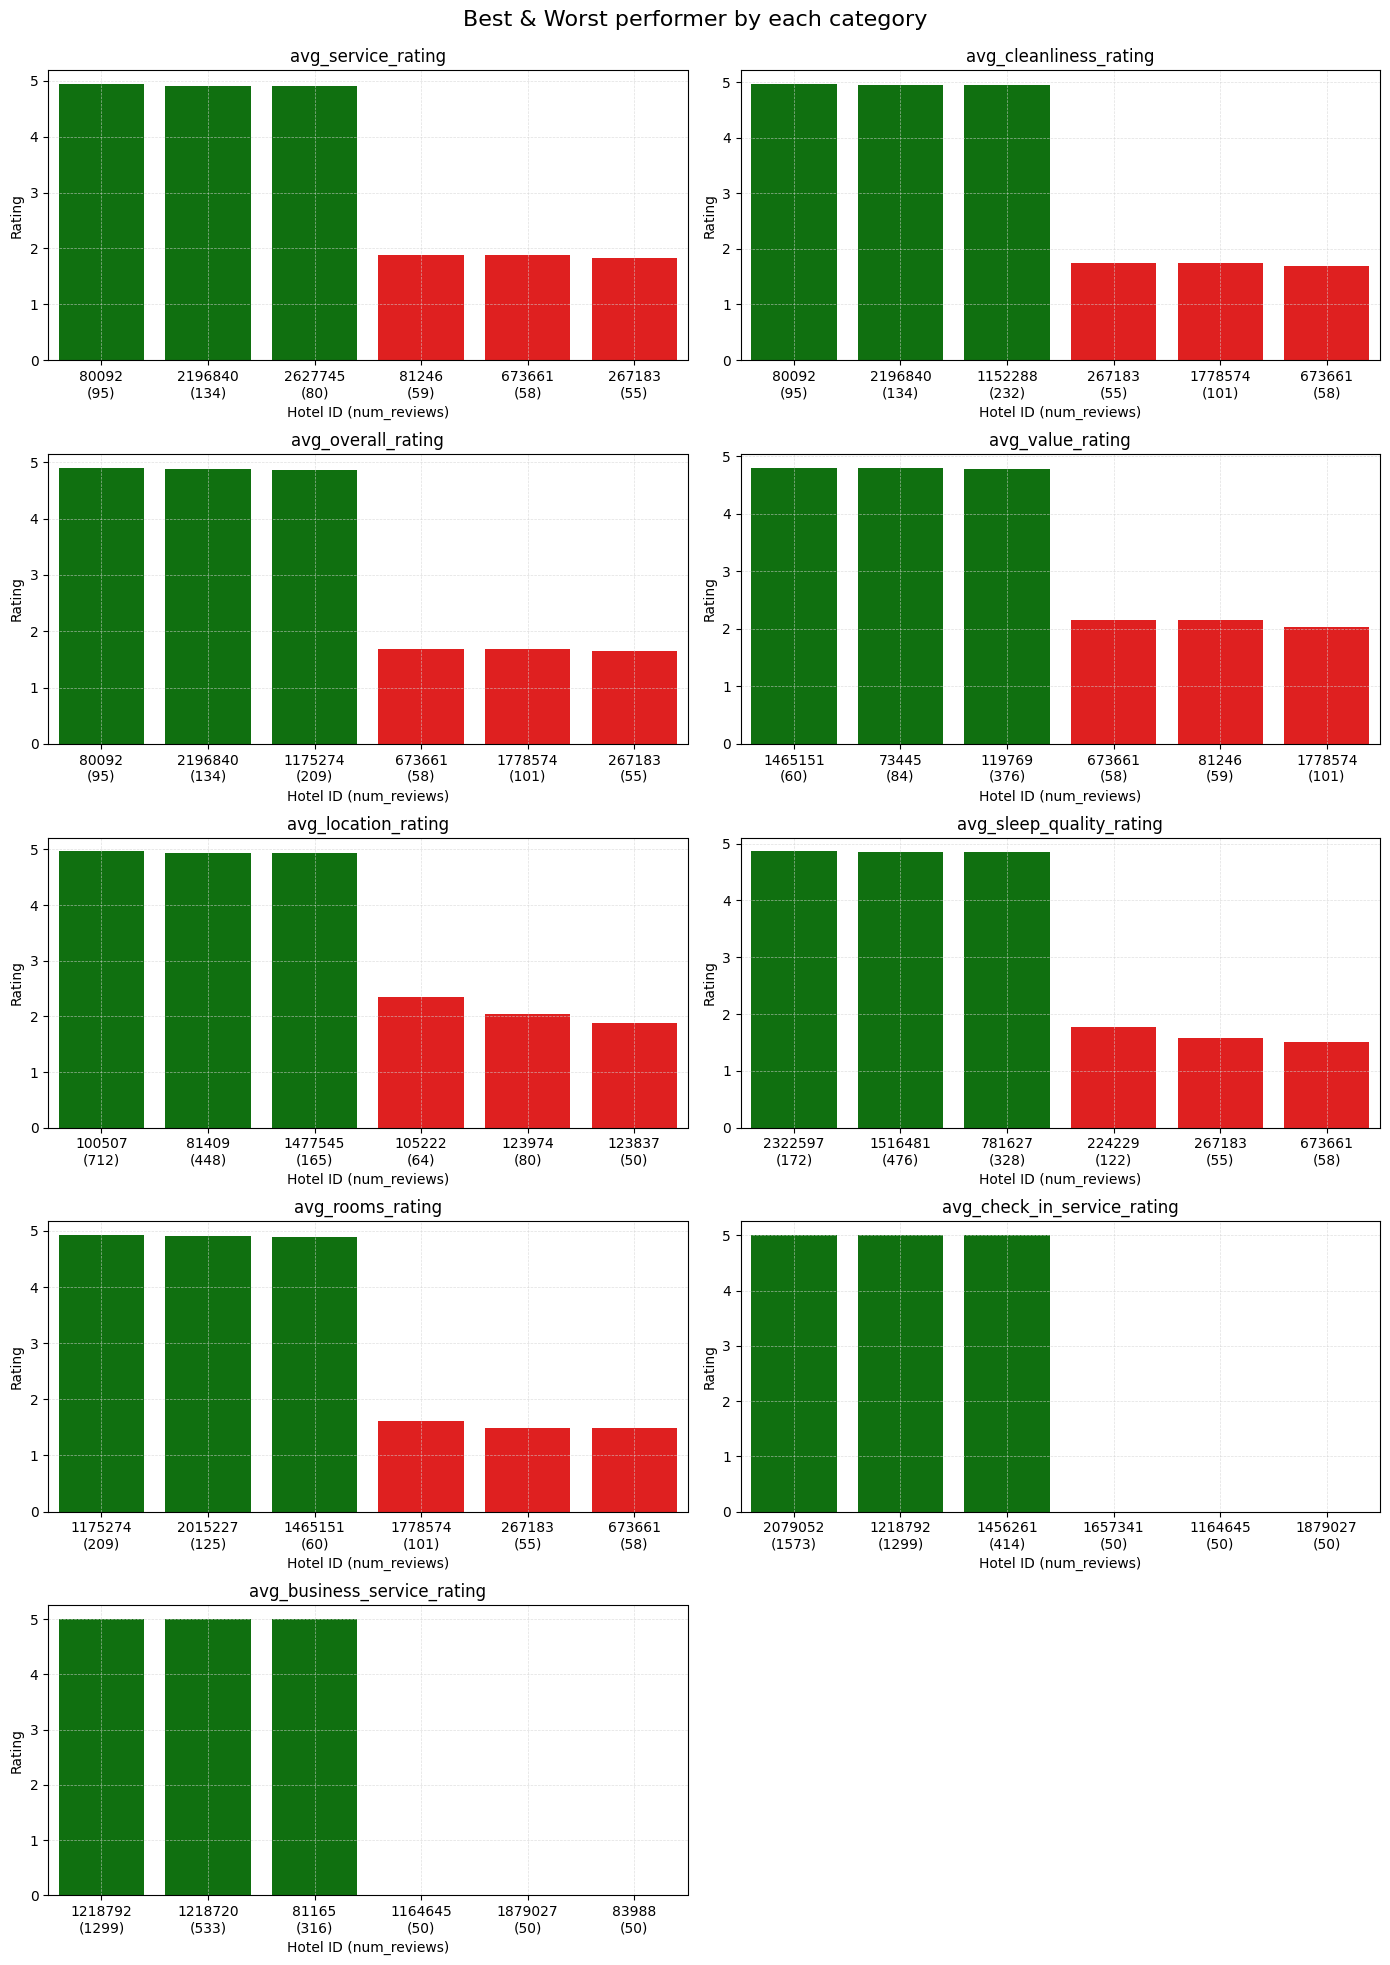

In [55]:
analyze_hotels_per_category_subplots(hotels_df, min_reviews=50)

In [56]:
hotels_df

,hotel_id,num_reviews,avg_service_rating,avg_cleanliness_rating,avg_overall_rating,avg_value_rating,avg_location_rating,avg_sleep_quality_rating,avg_rooms_rating,avg_check_in_service_rating,avg_business_service_rating,service_rating_variance,cleanliness_rating_variance,overall_rating_variance,value_rating_variance,location_rating_variance,sleep_quality_rating_variance,rooms_rating_variance,check_in_service_rating_variance,business_service_rating_variance
0,214197,1825,2.363836,2.306301,2.261370,2.617534,4.433425,2.595794,2.065205,2.421053,2.265306,1.468153,1.620845,1.453904,2.086366,0.883815,1.695452,1.193036,1.562327,0.666667
1,122005,1774,3.911499,4.221533,3.949267,3.858512,4.665163,4.098581,3.717587,3.623377,3.843137,1.153833,0.710408,0.929920,1.129118,0.362517,0.869507,1.055106,0.693878,0.960000
2,93520,1739,3.522714,3.600920,3.550316,3.557217,4.687752,3.813973,3.456009,2.994012,2.568182,1.587216,1.522748,1.454920,1.514815,0.306288,1.320919,1.417281,2.148760,1.867769
3,93562,1685,4.252819,4.217804,4.077151,4.016617,4.670623,3.936960,3.997033,4.369369,3.757576,0.953324,0.886312,0.999140,1.165390,0.340073,1.365682,1.148491,0.612188,0.997732
4,93618,1647,3.993321,4.101396,3.828780,3.408622,4.602914,4.099425,3.680631,4.134328,3.474359,1.611862,1.177829,1.397046,1.634697,0.568310,1.178711,1.408764,1.472222,0.617284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3375,98937,1,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,NaN
3376,1872507,1,5.000000,5.000000,5.000000,4.000000,5.000000,5.000000,5.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
3377,1743425,1,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
3378,1632579,1,1.000000,2.000000,1.000000,1.000000,1.000000,NaN,2.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,NaN


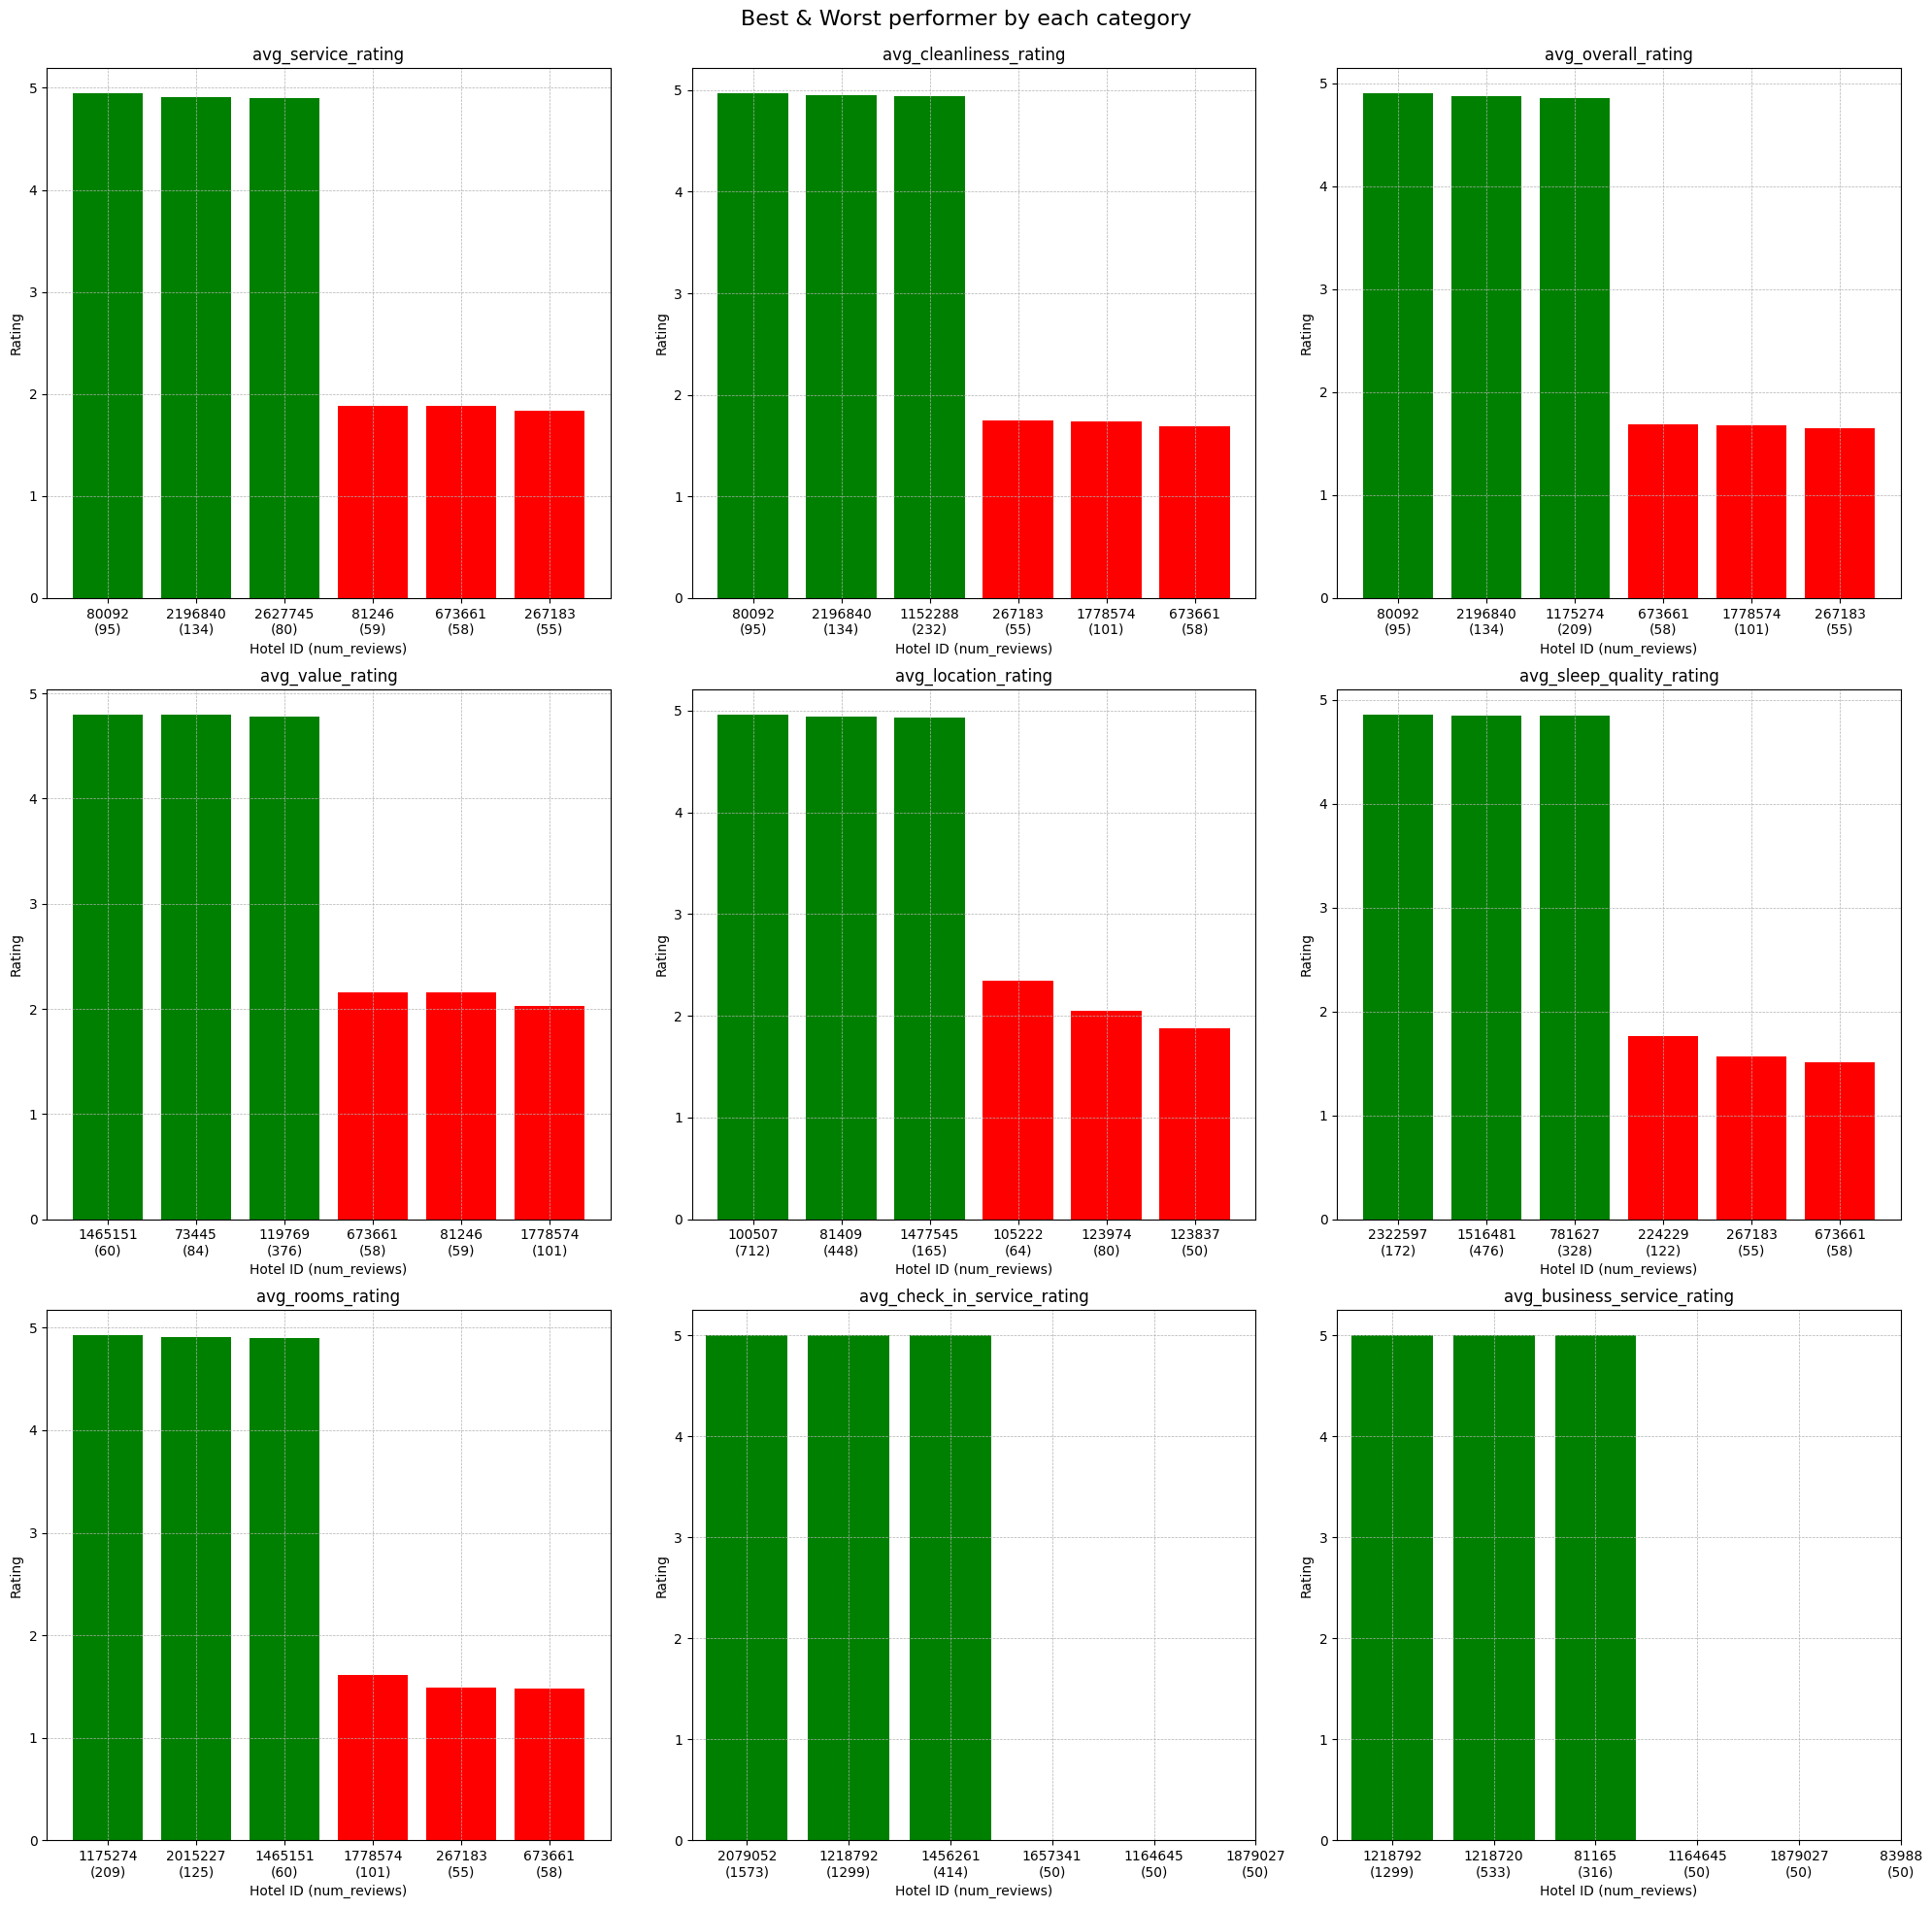

In [64]:
rating_cols = ['avg_service_rating','avg_cleanliness_rating', 'avg_overall_rating', 'avg_value_rating', 'avg_location_rating', 'avg_sleep_quality_rating', 'avg_rooms_rating','avg_check_in_service_rating', 'avg_business_service_rating']
vars_cols = ['service_rating_variance','cleanliness_rating_variance', 'overall_rating_variance', 'value_rating_variance', 'location_rating_variance', 'sleep_quality_rating_variance', 'rooms_rating_variance','check_in_service_rating_variance', 'business_service_rating_variance']

# Minimum threshold of review to be considered for calculation (hotel with only 1 rating with 5 stars would dominate without this filtering process)
min_reviews=50

# number of best and worst hotels to show
top_n = 3

# Remove hotels with num_reviews lower than threshold
df_filtered = hotels_df[hotels_df['num_reviews'] >= min_reviews].copy()

# Prepare subplot
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(20, 20))
ax = ax.flatten()

for i, col in enumerate(rating_cols):
    
    # Getting the variance column of the corresponding avg
    var_col = vars_cols[i]
    
    # Sort hotels by highest rating, highest numbers of reviews, then by lowest variance
    df_sorted = df_filtered.sort_values(
        by=[col, 'num_reviews', var_col],
        ascending=[False, False, True]
    )
    
    # Select best and worst n
    best_n = df_sorted.head(top_n)
    worst_n = df_sorted.tail(top_n)
    
    # Combine for plotting
    combined = pd.concat([best_n, worst_n])
    
    # create x axis labels with hotel_id and the num of reviews
    x_labels = [f"{hid}\n({rev})" for hid, rev in zip(combined['hotel_id'], combined['num_reviews'])]
    x_pos = range(len(combined))
    
    # Color for the bar
    colors = ['green'] * len(best_n) + ['red'] * len(worst_n)
    
    # Plot the bar plot
    ax[i].bar(x_pos, combined[col].values, color=colors)
    
    ax[i].grid(linestyle='--', linewidth=0.5)
    ax[i].set_title(f"{col}")
    ax[i].set_ylabel("Rating")
    ax[i].set_xlabel("Hotel ID (num_reviews)")
    ax[i].set_xticks(x_pos)
    ax[i].set_xticklabels(x_labels)

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.suptitle("Best & Worst performer by each category", fontsize=16)
plt.show()

### **c. Repeating visitor? mobile vs non mobile? fast and late review (3 mos threshold)?**

### **d. Best compliment Keyword for each hotels?**

My idea is to normalize the reviews, and check using tf-idf

In [ ]:
reviews_df.head(2)

In [ ]:
# Constants
PUNCTUATION = """!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~“”‘’"""
TOP_K_KEYWORDS = 10 # top k number of keywords to retrieve in a ranked document
STOPWORD_PATH = "../src/stopwords.txt"
# PAPERS_PATH = "/kaggle/input/nips-papers-1987-2019-updated/papers.csv"

In [ ]:
keyword_df = reviews_df.copy()
keyword_df = keyword_df[['hotel_id', 'title', 'text']]

In [ ]:
from utils import (
    clean_text,
    get_stopwords_list,
    get_keywords,
)

keyword_df['title'] = keyword_df['title'].apply(lambda x: clean_text(x, punctuation=PUNCTUATION))
keyword_df['text'] = keyword_df['text'].apply(lambda x: clean_text(x, punctuation=PUNCTUATION))

In [ ]:
keyword_df

In [ ]:
corpora_title = keyword_df['title'].to_list()
corpora_text = keyword_df['text'].to_list()

combined_corpora = [
    f"{title} {text}"
    for title, text in zip(corpora_title, corpora_text)
]
combined_corpora[:5]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

#load a set of stop words
stopwords=get_stopwords_list(STOPWORD_PATH)

# Initializing TF-IDF Vectorizer with stopwords
vectorizer = TfidfVectorizer(stop_words=stopwords, smooth_idf=True, use_idf=True)

# Creating vocab with our corpora
# Exlcluding first 10 docs for testing purpose
vectorizer.fit_transform(combined_corpora)

# Storing vocab
feature_names = vectorizer.get_feature_names_out()

In [ ]:
result = []
for doc in combined_corpora:
    df = {}
    df['full_text'] = doc
    df['top_keywords'] = get_keywords(vectorizer, feature_names, doc, top_k_keywords=TOP_K_KEYWORDS)
    result.append(df)
    
final = pd.DataFrame(result)
final

We got the keyword, although it's not 100% accurate

In [ ]:
# Quiet mode
import os
import warnings
import logging

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="n_jobs value.*", category=UserWarning)
warnings.filterwarnings("ignore", message="Glyph .* missing from font\\(s\\)", category=UserWarning)

logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [ ]:
import itertools

# Flatten all top_keywords into one set
all_words = set(itertools.chain.from_iterable(final['top_keywords']))
print(f"Number of unique words: {len(all_words)}")

from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

# Get embeddings
word_list = list(all_words)
embeddings = model.encode(word_list)
print(embeddings.shape)  # (num_words, embedding_dim)

import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_components=2, random_state=42)
embeddings_2d = reducer.fit_transform(embeddings)

print(embeddings_2d.shape)  # (num_words, 2)

plt.figure(figsize=(12, 12))
plt.scatter(embeddings_2d[:,0], embeddings_2d[:,1], alpha=0.5)

# Optional: label top words (might get cluttered)
for i, word in enumerate(word_list[:200]):
    plt.text(embeddings_2d[i,0], embeddings_2d[i,1], word, fontsize=8)

plt.title("Word Embeddings Projected to 2D")
plt.show()


### **e. Which rating category contributes the most to the overall rating?**

check the correlation of the scores. this can help the hotel to decide where to invest next

### **f. Trend in the stars during the years for each hotel or for each location group**

### **g. "How does my hotel perform?"**

by inputting the average rating of the current hotel, we can show graph like "you perform better than 90% of hotels worldwide, and 95% in the same region".

### **h. top 5 hotel and bottom 5 hotel per location**

### **i. best and worst service per location to tell which countries are better in certain category**

### **j. does mobile reviews is shorter and less helpful?**

### **k. Do fast reviews tend to be more negative?**

### **l. are experienced travelers more critical than casual reviewers?**

---

Column Explanation:
* title
* text
* date_stayed
* hotel_id
* num_helpful_votes
* review_date
* review_id
* via_mobile
* service_rating
* cleanliness_rating
* overall_rating
* value_rating
* location_rating
* sleep_quality_rating
* rooms_rating
* check_in_service_rating
* business_service_rating
* author_key

### Close connection

In [ ]:
conn.close()

Issue:
- is the location denotes the hotel's location or the user
- where is the complete dataset .db
- data validation step is still incomplete (date checking and else)
- column description step is missing yet essential for us to make
- feature engineering part needs more ideas